# Описание проекта

Целью исследования является помощь бизнесу оптимизировать управление персоналом: бизнес предоставляет данные и ожидает предложений по предотвращению финансовых потерь и оттока сотрудников. 

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании, который получили из формы обратной связи.

Необходимо предсказать уровень удовлетворённости сотрудника на основе данных заказчика и построить модель, которая сможет предсказать то, что сотрудник уволится из компании.

**Для проведения исследования доступны следующие данные:** 
- тренировочный датасет с характеристиками сотрудников компании и целевым признаком "уровень удовлетворённости сотрудника";
- тестовый датасет с характеристиками сотрудников компании;
- тестовый датасет с целевым признаком "уровень удовлетворённости сотрудника".

- тренировочный датасет с характеристиками сотрудников компании и входным признаком-индикатором увольнения сотрудников;
- тестовый датасет с характеристиками сотрудников компании;
- тестовый датасет с входным признаком-индикатором увольнения сотрудников.

**План проведения исследования:**
- изучим данные;
- проведём предобработку;
- выполним исследовательский и корреляционный анализ данных;
- выберем лучшую модель для прогноза уровня удовлетворённости сотрудника на основе данных заказчика;
- построим модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

## Подготовка к чтению данных

<font size="3"> Импортируем необходимые библиотеки:

In [1]:
pip install missingno phik scikit-learn==1.3.0. matplotlib==3.8.3 optuna -q

Note: you may need to restart the kernel to use updated packages.


In [6]:
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import optuna
import pandas as pd
import phik
import scipy.stats as st
import seaborn as sns

from optuna import distributions
from optuna.integration import OptunaSearchCV
from phik.report import plot_correlation_matrix

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

<font size="3">
Зададим настройки:

In [7]:
sns.set_theme(style="darkgrid", palette="icefire")
pd.set_option('display.max_columns', None)
pd.options.display.float_format ='{:,.3f}'.format

---

## Предсказание уровня удовлетворённости сотрудника

<font size="3"> Первая задача исследования - выбор лучшей модели для прогноза уровня удовлетворённости сотрудника на основе данных заказчика. 

### Чтение данных

<font size="3">

- **Датасет `train_job_satisfaction_rate`**

<font size="3"> Считаем тренировочную выборку с характеристиками сотрудников компании и целевым признаком "уровень удовлетворённости сотрудника" и сохраним в переменную `data_rate`:

In [8]:
try:
    data_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
except:
    data_rate = pd.read_csv('/Users/kasper/Documents/Projects/Сборный-2 HR/train_job_satisfaction_rate.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `data_rate` на экран:

In [9]:
data_rate.head(20)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.580
1,653870,hr,junior,high,2,no,no,5,38400,0.760
2,184592,sales,junior,low,1,no,no,2,12000,0.110
3,171431,technology,junior,low,4,no,no,2,18000,0.370
4,693419,hr,junior,medium,1,no,no,3,22800,0.200
5,405448,hr,middle,low,7,no,no,4,30000,0.780
6,857135,sales,sinior,medium,9,no,no,3,56400,0.560
7,400657,purchasing,middle,high,9,no,no,3,52800,0.440
8,198846,hr,junior,low,1,no,no,2,13200,0.140
9,149797,technology,middle,high,6,no,no,3,54000,0.470


<font size="3">

- **Датасет `test_features`**

<font size="3"> Считаем тестовую выборку с входными признаками и сохраним в переменную `features_rate`:

In [10]:
try:
    features_rate = pd.read_csv('/datasets/test_features.csv')
except:
    features_rate = pd.read_csv('/Users/kasper/Documents/Projects/Сборный-2 HR/test_features.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `features_rate` на экран:

In [11]:
features_rate.head(20)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
5,429973,purchasing,middle,medium,6,no,no,3,42000
6,850699,technology,junior,medium,3,no,no,3,26400
7,500791,sales,middle,high,9,no,no,4,49200
8,767867,marketing,middle,high,3,no,yes,4,62400
9,937235,sales,junior,medium,1,no,yes,3,26400


<font size="3">

- **Датасет `test_target_job_satisfaction_rate`**

<font size="3"> Считаем датасет с целевым признаком "уровень удовлетворённости сотрудника" и сохраним в переменную `target_rate`:

In [12]:
try:
    target_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
except:
    target_rate = pd.read_csv('/Users/kasper/Documents/Projects/Сборный-2 HR/test_target_job_satisfaction_rate.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `target_rate` на экран:

In [13]:
target_rate.head(20)

,id,job_satisfaction_rate
0,130604,0.740
1,825977,0.750
2,418490,0.600
3,555320,0.720
4,826430,0.080
5,817219,0.760
6,269033,0.640
7,962356,0.380
8,649052,0.140
9,532834,0.590


### Изучение датафреймов

<font size="3">
    
Изучим структуру и полноту полученных датафреймов

- **Датафрейм `data_rate`**

In [14]:
data_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


<Axes: >

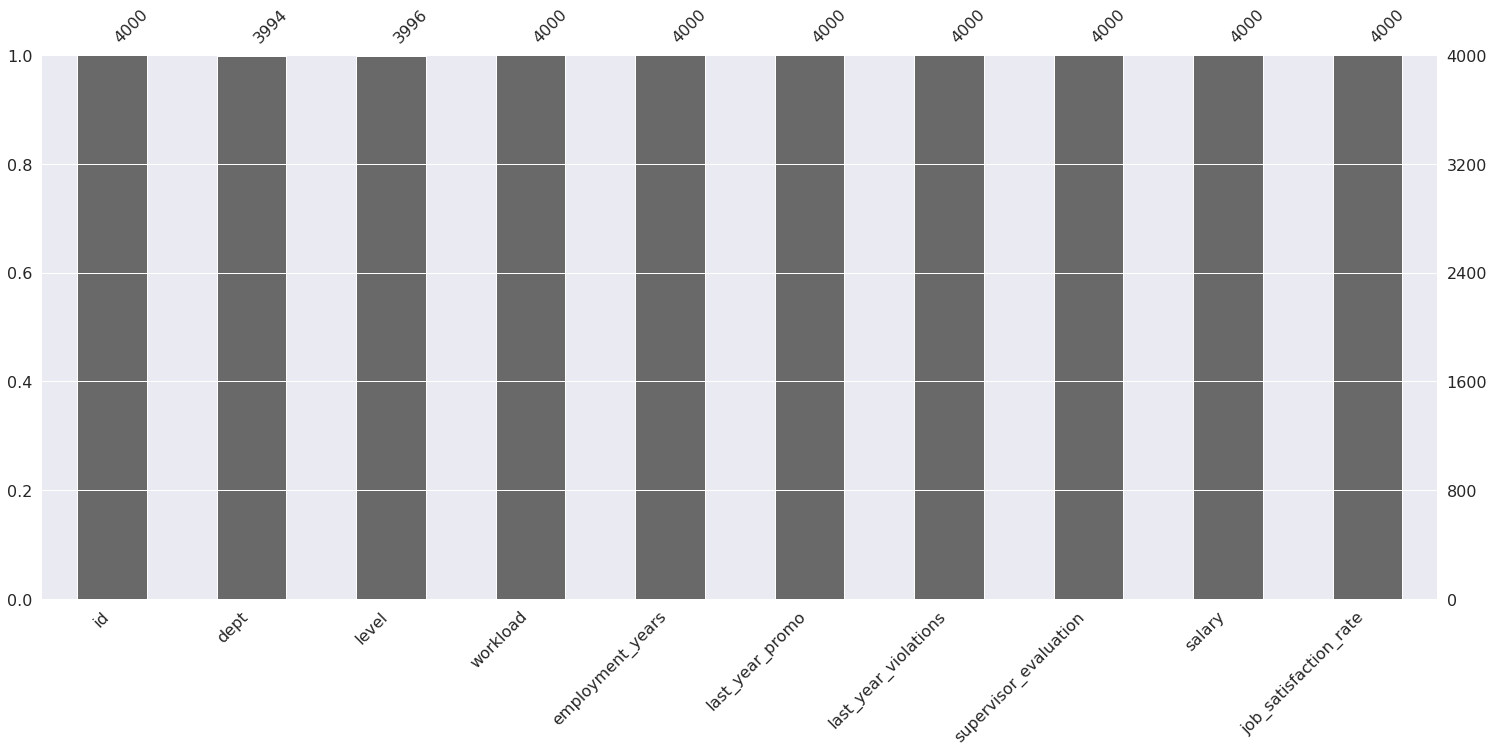

In [15]:
msno.bar(data_rate)

<font size="3">

- **Датафрейм `features_rate`**

In [16]:
features_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


<Axes: >

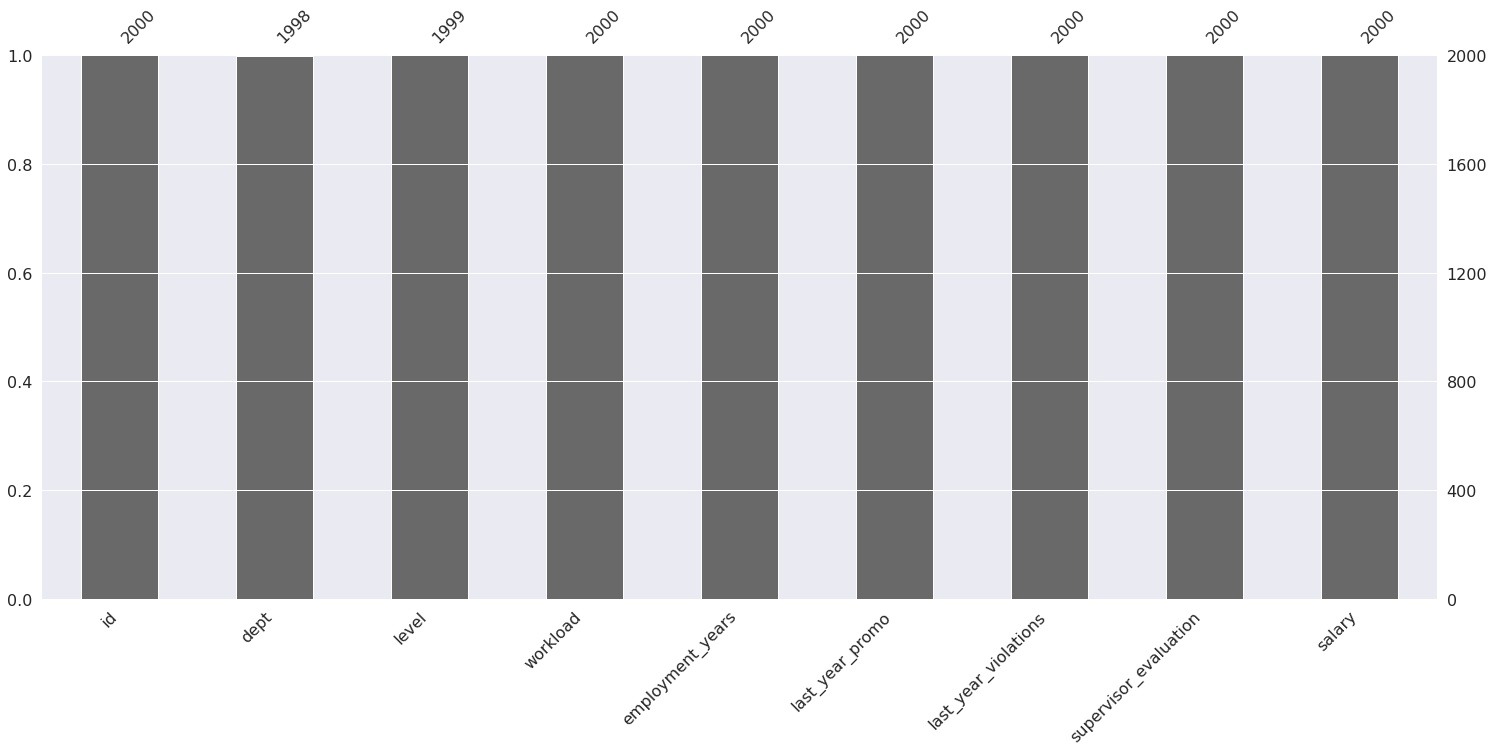

In [17]:
msno.bar(features_rate)

<font size="3">

- **Датафрейм `target_rate`**

In [18]:
target_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


<Axes: >

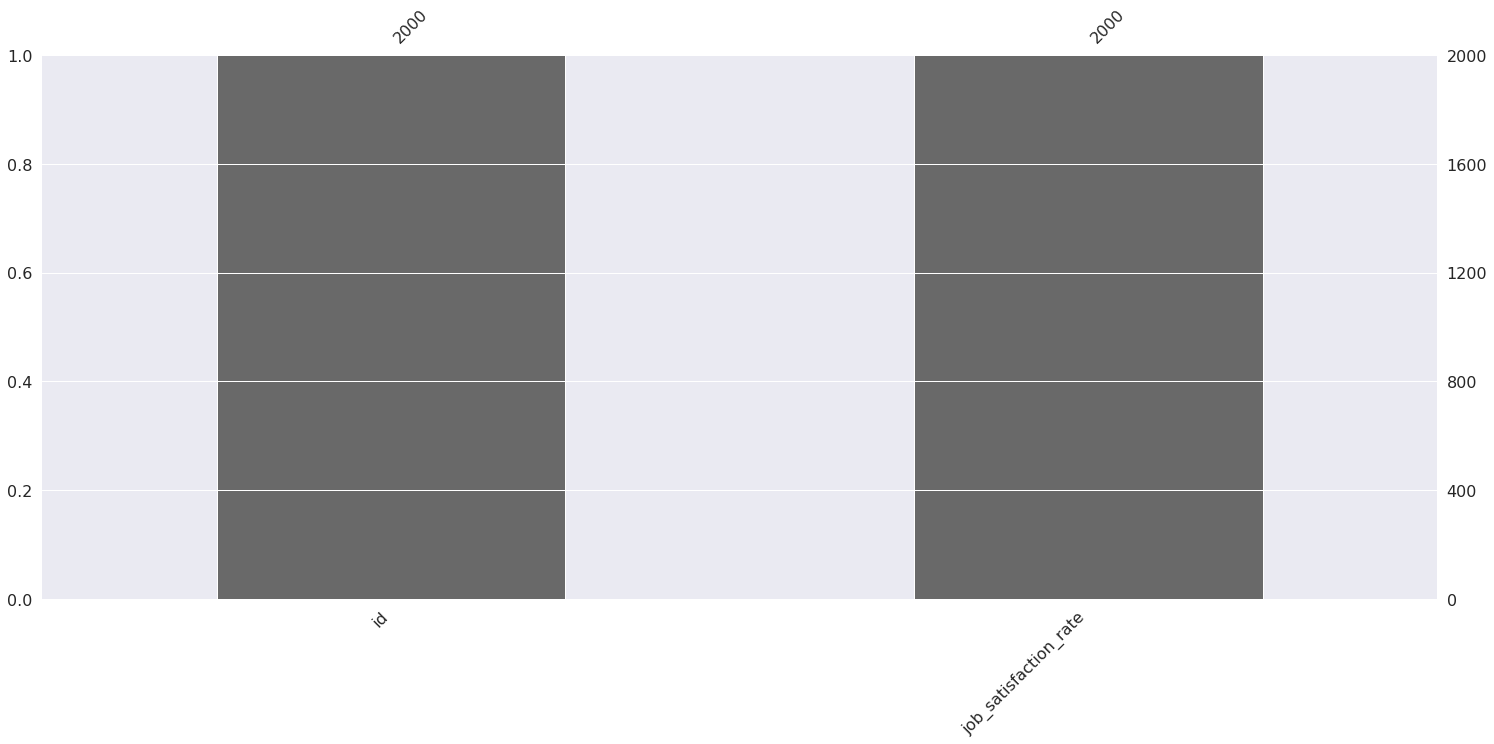

In [19]:
msno.bar(target_rate)

<font size="3">
    
**Вывод:**

Полученные датафреймы содержат следующие данные:

- **датафрейм `data_rate`:**
  * `id` — уникальный идентификатор сотрудника;
  * `dept` — отдел, в котором работает сотрудник;
  * `level` — уровень занимаемой должности;
  * `workload` — уровень загруженности сотрудника;
  * `employment_years` — длительность работы в компании (в годах);
  * `last_year_promo` — показывает, было ли повышение за последний год;
  * `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
  * `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
  * `salary` — ежемесячная зарплата сотрудника;
  * `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании - целевой признак;

---

- **датафрейм `features_rate`:**
  * `id` — уникальный идентификатор сотрудника;
  * `dept` — отдел, в котором работает сотрудник;
  * `level` — уровень занимаемой должности;
  * `workload` — уровень загруженности сотрудника;
  * `employment_years` — длительность работы в компании (в годах);
  * `last_year_promo` — показывает, было ли повышение за последний год;
  * `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
  * `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
  * `salary` — ежемесячная зарплата сотрудника.
  
---

- **датафрейм `target_rate`:**
  * `id` — уникальный идентификатор сотрудника;
  * `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании - целевой признак;
    
---

Предварительно можно утверждать, что данных достаточно для проведения анализа. В датасетах имеются пропущенные значения.

Столбцы датафреймов именованы корректно, стоит подробнее изучить тип имеющихся данных, а также в данных могут присутствовать дубликаты.

Необходима предобработка данных.

---

## Предобработка данных

### Тип данных

<font size="3">
    
Убедимся, что в датафреймах корретный тип данных.
    
- **датафрейм `data_rate`:**

In [20]:
data_rate.dtypes

id                         int64
dept                      object
level                     object
workload                  object
employment_years           int64
last_year_promo           object
last_year_violations      object
supervisor_evaluation      int64
salary                     int64
job_satisfaction_rate    float64
dtype: object

- **датафрейм `features_rate`:**

In [21]:
features_rate.dtypes

id                        int64
dept                     object
level                    object
workload                 object
employment_years          int64
last_year_promo          object
last_year_violations     object
supervisor_evaluation     int64
salary                    int64
dtype: object

- **датафрейм `target_rate`:**

In [22]:
target_rate.dtypes

id                         int64
job_satisfaction_rate    float64
dtype: object

<font size="3">

---
**Вывод**

Все столбцы в датафреймах содержат корректный тип данных: количественные столбцы имеют тип `float64` и `int64`, категориальные - тип `object`.

### Проверка пропусков

<font size="3"> Гистограммы `msno` показали наличие пропущенных значений в датафреймах `data_rate` и `features_rate`, изучим их подробнее:

In [23]:
data_rate.isna().sum()

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [24]:
features_rate.isna().sum()

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

<font size="3">

---
**Вывод**

Пропущенные значения обнаружены в категориальных признаках `dept` и `level`. 
    
Заполнение пропусков наиболее часто встречающимся значением не гарантирует того, что данные будут восстановлены корректно. Заполним подобные значения категорией-заглушкой, чтобы для построения прогноза модель использовала только достоверные данные.
    
Пропущенные значения обработаем в шаге пайплайна по выбранному алгоритму.

### Проверка явных дубликатов

<font size="3">
    
Проверим наличие явных дубликатов в датафреймах.

- **датафрейм `data_rate`:**

In [25]:
data_rate.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

<font size="3">
    
- **датафрейм `features_rate`:**

In [26]:
features_rate.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

<font size="3">
    
- **датафрейм `target_rate`:**

In [27]:
target_rate.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

### Проверка неявных дубликатов

<font size="3">
    
Проверим категориальные столбцы датафреймов на наличие неявных дубликатов.

<font size="3">

- **датафрейм `data_rate`**
    
Столбец `dept`:

In [28]:
data_rate['dept'].value_counts()

sales         1512
technology     866
purchasing     610
marketing      550
hr             456
Name: dept, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `level`:

In [29]:
data_rate['level'].value_counts()

junior    1894
middle    1744
sinior     358
Name: level, dtype: int64

<font size="3"> Переименуем значение "sinior" в "senior".

In [30]:
data_rate['level'] = data_rate['level'].replace(
    ['sinior'], 
    'senior', 
    regex=True
)

<font size="3"> Проверим результат:

In [31]:
data_rate['level'].value_counts()

junior    1894
middle    1744
senior     358
Name: level, dtype: int64

<font size="3"> Категории именованы корректно, неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `workload`:

In [32]:
data_rate['workload'].value_counts()

medium    2066
low       1200
high       734
Name: workload, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `last_year_promo`:

In [33]:
data_rate['last_year_promo'].value_counts()

no     3880
yes     120
Name: last_year_promo, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `last_year_violations`:

In [34]:
data_rate['last_year_violations'].value_counts()

no     3441
yes     559
Name: last_year_violations, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3">

- **датафрейм `features_rate`**
    
Столбец `dept`:

In [35]:
features_rate['dept'].value_counts()

sales         763
technology    455
marketing     279
purchasing    273
hr            227
                1
Name: dept, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `level`:

In [36]:
features_rate['level'].value_counts()

junior    974
middle    854
sinior    171
Name: level, dtype: int64

<font size="3"> Переименуем значение "sinior" в "senior".

In [37]:
features_rate['level'] = features_rate['level'].replace(
    ['sinior'], 
    'senior', 
    regex=True
)

<font size="3"> Проверим результат:

In [38]:
features_rate['level'].value_counts()

junior    974
middle    854
senior    171
Name: level, dtype: int64

<font size="3"> Категории именованы корректно, неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `workload`:

In [39]:
features_rate['workload'].value_counts()

medium    1043
low        593
high       363
             1
Name: workload, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `last_year_promo`:

In [40]:
features_rate['last_year_promo'].value_counts()

no     1937
yes      63
Name: last_year_promo, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `last_year_violations`:

In [41]:
features_rate['last_year_violations'].value_counts()

no     1738
yes     262
Name: last_year_violations, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3">

**Вывод**

Для корректного проведения исследования выполнена предобработка данных:

- Проверены типы данных;
- Изучены пропуски в датафреймах;
- Проверены и обработаны дубликаты в датафреймах, в том числе и неявные.

---

## Исследовательский анализ данных

<font size="3"> Проведём исследовательский анализ всех признаков датафрейма `data_rate`.

### Количественные признаки


<font size="3"> Напишем функцию `visuals`, которая построит гистограмму распределения, коробчатую диаграмму и выведет метод `describe()`:

In [42]:
def visuals(df, cat):
    display(df[cat].describe())
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
    
    df[cat].plot(kind='hist', bins=20, ax=axes[0])
    axes[0].set_title('Гистограмма распределения', fontsize=14)
    axes[0].set_ylabel('Частота встречаемости')
    axes[0].set_xlabel('Наблюдаемые значения')
    
    df[cat].plot(kind='box', ax=axes[1], rot=0)
    axes[1].set_title('Разброс значений признаков', fontsize=14)
    axes[1].set_xlabel('Категория')
    axes[1].set_ylabel('Наблюдаемые значения')
    plt.show()

<font size="3">
    
- **Признак `employment_years`:**

count   4,000.000
mean        3.719
std         2.543
min         1.000
25%         2.000
50%         3.000
75%         6.000
max        10.000
Name: employment_years, dtype: float64

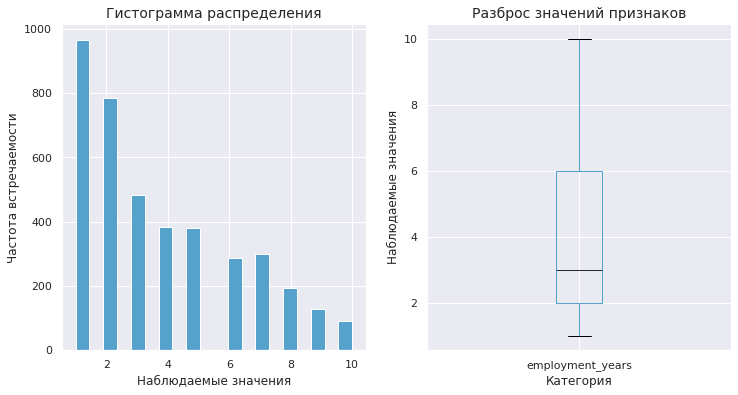

In [43]:
visuals(data_rate, 'employment_years')

<font size="3">
    
**Вывод:**
    
Признак `employment_years` отображает длительность работы сотрудника в компании в годах. 
    
Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 2 до 6 лет со средним значением в 3.7.

Выбросы и аномалии в данных отсутствуют.

---
<font size="3">
    
- **Признак `supervisor_evaluation`:**

count   4,000.000
mean        3.477
std         1.009
min         1.000
25%         3.000
50%         4.000
75%         4.000
max         5.000
Name: supervisor_evaluation, dtype: float64

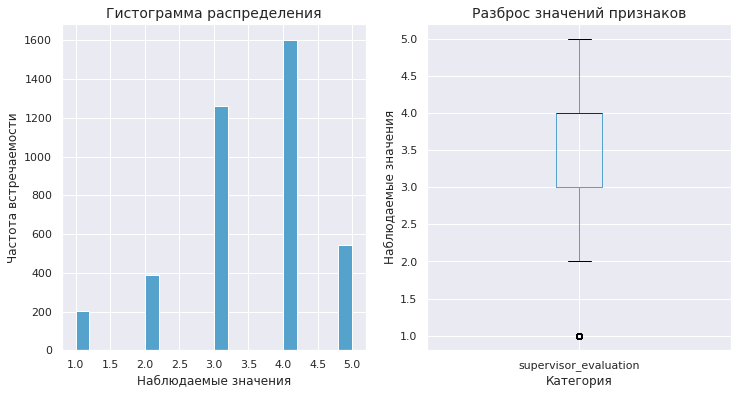

In [44]:
visuals(data_rate, 'supervisor_evaluation')

<font size="3">
    
**Вывод**

Признак `supervisor_evaluation` отображает оценку качества работы сотрудника, которую дал его руководитель. 
    
Распределение признака асимметрично влево, большинство значений располагается в промежутке от 3 до 4 со средним значением в 3.5 баллов.

Выбросы и аномалии в данных отсутствуют.

---
<font size="3">
    
- **Признак `salary`:**

count    4,000.000
mean    33,926.700
std     14,900.704
min     12,000.000
25%     22,800.000
50%     30,000.000
75%     43,200.000
max     98,400.000
Name: salary, dtype: float64

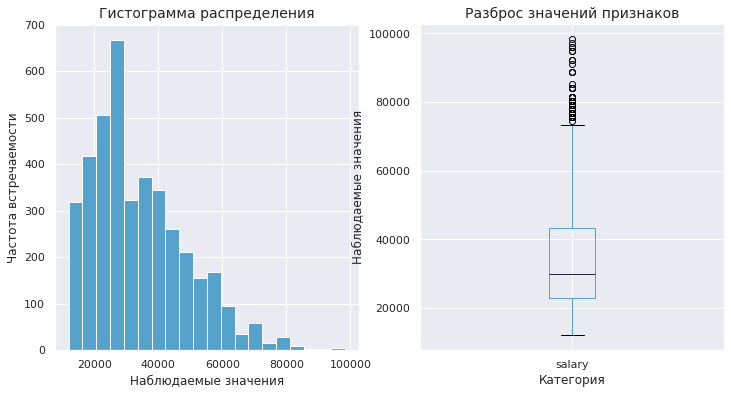

In [45]:
visuals(data_rate, 'salary')

<font size="3">
    
**Вывод:**
    
Признак `salary` отображает ежемесячную заработную плату сотрудника. 
    
Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 23000 до 43000 со средним значением в 34000 рублей.

Выбросы и аномалии в данных отсутствуют.

---
<font size="3">
    
- **Признак `job_satisfaction_rate`:**

count   4,000.000
mean        0.534
std         0.225
min         0.030
25%         0.360
50%         0.560
75%         0.710
max         1.000
Name: job_satisfaction_rate, dtype: float64

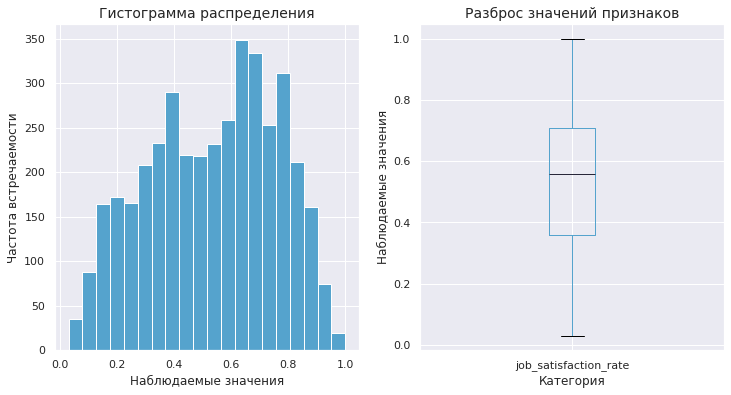

In [46]:
visuals(data_rate, 'job_satisfaction_rate')

<font size="3">
    
**Вывод**

Целевой признак `job_satisfaction_rate` показывает уровень удовлетворённости сотрудника работой в компании.
    
Признак распределён нормально, большинство значений располагается в промежутке от 0.36 до 0.71 дней со средним значением в 0.53.

Выбросы и аномалии отсутствуют.

---

### Категориальные признаки

<font size="3">
    
Изучим категориальные признаки датафрейма `data_rate`.

Напишем функцию, которая визуализирует признак с помощью столбчатой гистограммы:

In [47]:
def cat_visuals(df, cat): 
    ax = sns.countplot(x=df[cat],
                   order=df[cat].value_counts(ascending=False).index);
    
    abs_values = df[cat].value_counts(ascending=False).values
    
    ax.bar_label(container=ax.containers[0], labels=abs_values)
    ax.set_title('Распределение категорий признака ' + cat)
    ax.set(xlabel='Категории', ylabel='Частота встречаемости')    
    ax.figure.set_size_inches(12,6);

<font size="3">
    
- **Признак `dept`:**

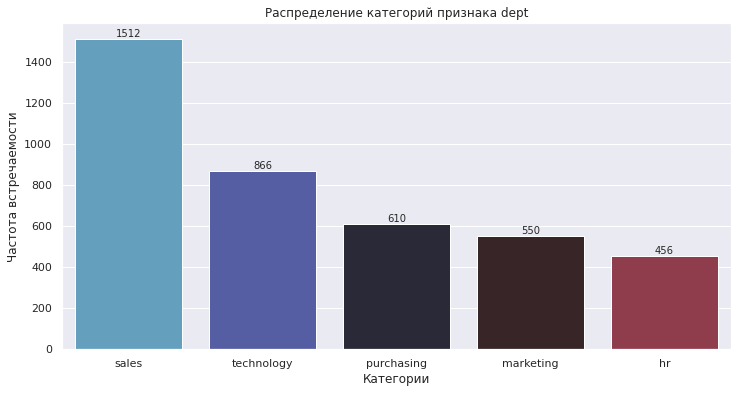

In [48]:
cat_visuals(data_rate, 'dept')

<font size="3">
    
**Вывод**

Признак `dept` представлен категориями: 
- «sales»
- «technology»
- «purchasing»
- «marketing»
- «hr»

В выборке преобладает департамент «sales».

---
<font size="3">
    
- **Признак `level`:**

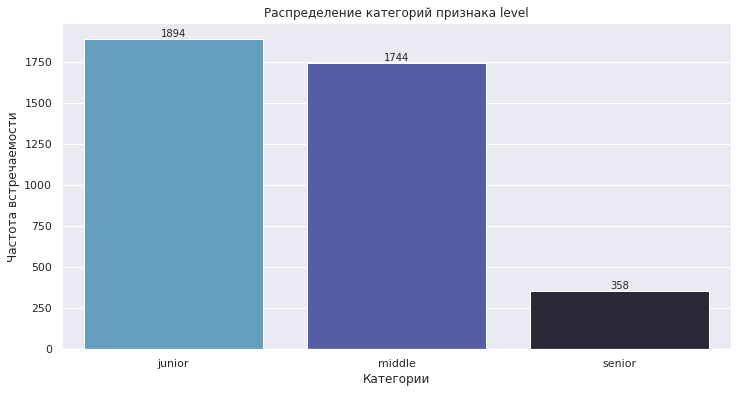

In [49]:
cat_visuals(data_rate, 'level')

<font size="3">
    
**Вывод**

Признак `level` представлен категориями: 
- «junior»
- «middle»
- «senior»

В выборке преобладает категория «junior».

---
<font size="3">
    
- **Признак `workload`:**

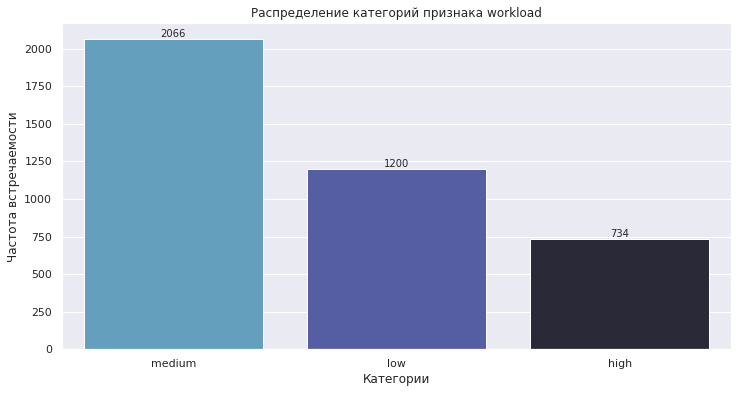

In [50]:
cat_visuals(data_rate, 'workload')

<font size="3">
    
**Вывод**

Признак `workload` представлен категориями: 
- «low»
- «medium»
- «high»

В выборке преобладает категория «medium».

---
<font size="3">
    
- **Признак `last_year_promo`:**

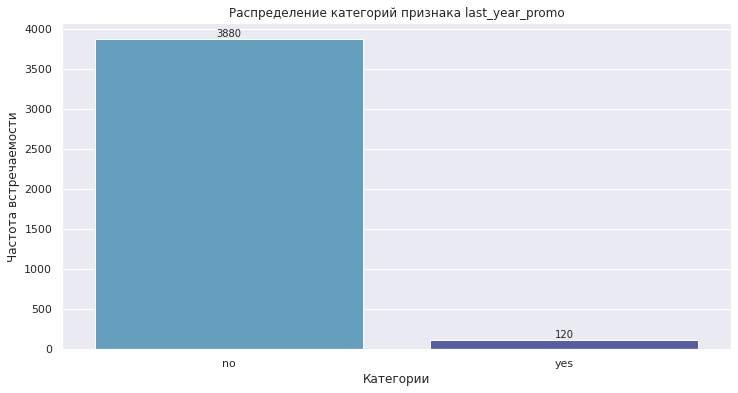

In [51]:
cat_visuals(data_rate, 'last_year_promo')

<font size="3">
    
**Вывод**

Признак `last_year_promo` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

---
<font size="3">
    
- **Признак `last_year_violations`:**

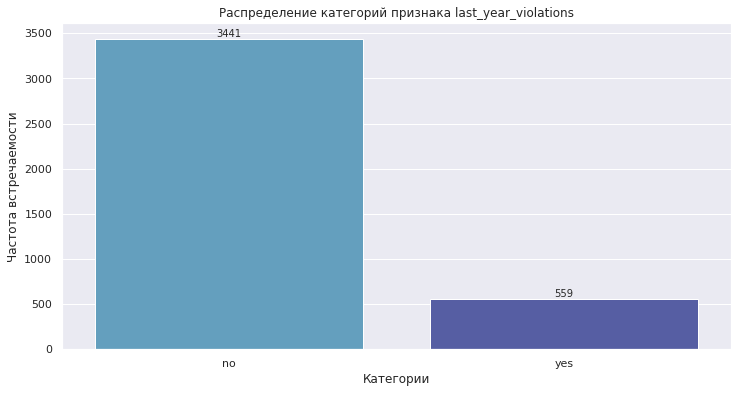

In [52]:
cat_visuals(data_rate, 'last_year_violations')

<font size="3">
    
**Вывод**

Признак `last_year_violations` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

---
<font size="3">

**Вывод**

В датафрейме `data_rate` 4 количественных и 5 категориальных признаков. 
    
Выбросов и аномалий в данных не обнаружено.

---

## Корреляционный анализ

<font size="3"> Проведём корреляционный анализ признаков датафрейма `data_rate`. 

Признак `job_satisfaction_rate` - целевой, изучим взаимосвязь входных признаков с целевым, а также выявим мультиколлинеарность признакового описания при его наличии.

<font size="3"> Корреляцию признаков рассмотрим с помощью матрицы корреляций `phik_matrix()`.

In [53]:
def phik_matrix(df):
    # список интервальных признаков
    interval_cols = df.select_dtypes(include='number').columns.tolist()
    
    # вычисление коэффициентов корреляции phi для датафрейма ferma
    phik_overview = df.phik_matrix(interval_cols=interval_cols)

    # визуализация тепловой карты коэффициентов корреляции
    plot_correlation_matrix(
        phik_overview.values,
        x_labels=phik_overview.columns,
        y_labels=phik_overview.index,
        title=r"Матрица корреляции $\phi_K$",
        fontsize_factor=1.5,
        figsize=(12, 9)
    )

<font size="3"> 
    
Построим матрицу для `data_rate`:

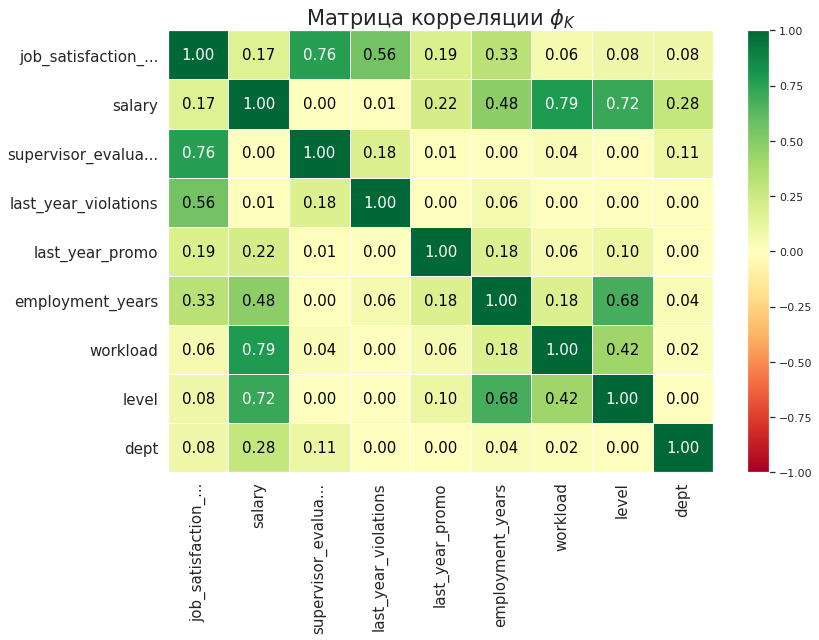

In [54]:
phik_matrix(data_rate.loc[:,'dept' : 'job_satisfaction_rate'])

<font size="3">

**Вывод**

Высокая зависимость с целевым признаком `job_satisfaction_rate` выявлена у признака `supervisor_evaluation`.

Заметная зависимость - у признака `last_year_violations`.
    
У остальных входных признаков умеренная либо слабая зависимость с целевым.

Мультиколлинеарность входных признаков не выявлена.

---
### Целевой признак

<font size="3"> Целевым в датафрейме `data_rate` является количественный признак `job_satisfaction_rate`.
    
    
Рассмотрим сопряжённость целевого признака и всеми признаками датафрейма.

#### Количественные признаки

<font size="3">
    
Изучим зависимость между целевым и количественными признаками датафрейма.

 
Для этого напишем функцию для построения графика `scatterplot`, которая визуализирует зависимость целевого признака от входных количественных признаков. 
    
Предварительно в теле функции сгруппируем датафрейм по входному количественному признаку и для построения графика возьмём среднее значение каждой группы. 

In [55]:
def target_numeric(quant):
    fig, axes = plt.subplots(figsize=(12,6))
    
    sns.scatterplot(data=data_rate.groupby(quant)[['job_satisfaction_rate']].mean(), \
                    x=quant, y="job_satisfaction_rate", ax=axes)\
    .set(title='Зависимость признаков "job_satisfaction_rate" и "' + quant + '"')

<font size="3">
    
- **Признак `employment_years`:**

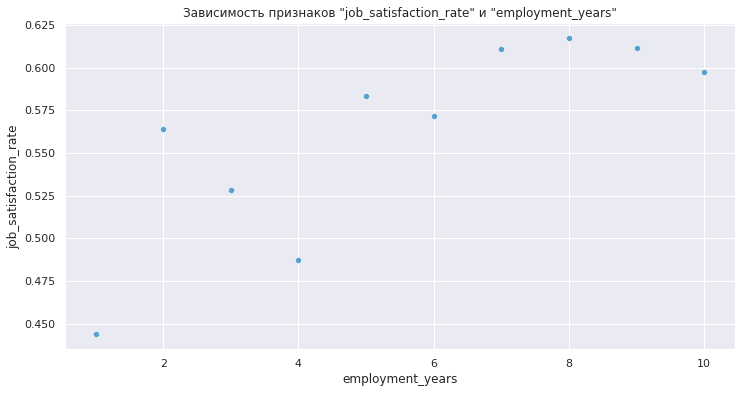

In [56]:
target_numeric ('employment_years')

<font size="3">
    
**Вывод**

Между целевым признаком `job_satisfaction_rate` и входным признаком `employment_years` отмечается умеренная зависимость: высокой длительности работы в компании соответствует более высокий уровень удовлетворённости сотрудника работой.

---

<font size="3">
    
- **Признак `supervisor_evaluation`:**

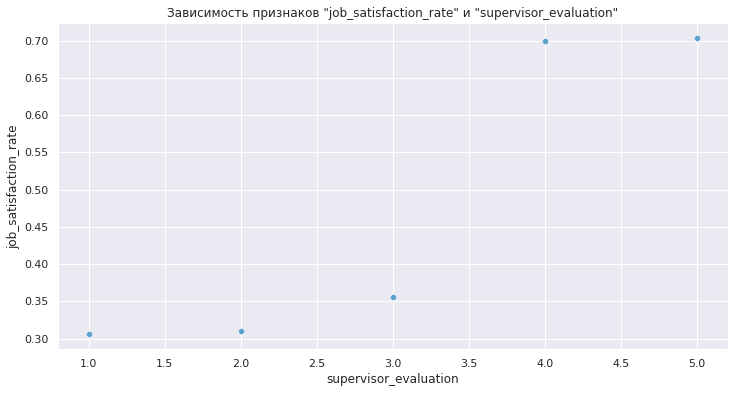

In [57]:
target_numeric ('supervisor_evaluation')

<font size="3">
    
**Вывод**

Между целевым признаком `job_satisfaction_rate` и входным признаком `supervisor_evaluation` отмечается высокая зависимость: более высоким значениям оценки качества работы сотрудника руководителем соответствует больший уровень удовлетворённости сотрудника работой.

---

<font size="3">
    
- **Признак `salary`:**

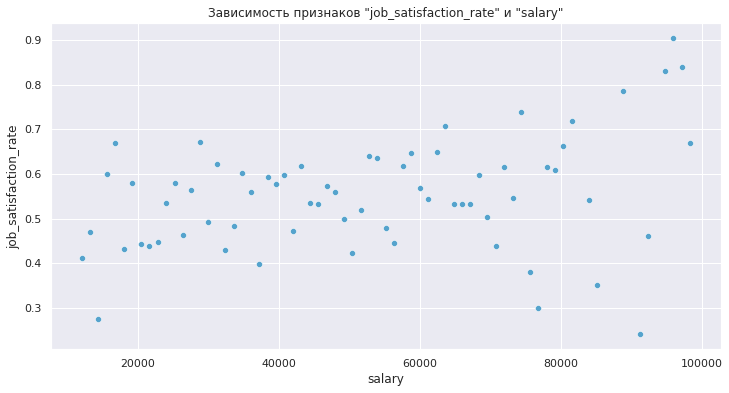

In [58]:
target_numeric ('salary')

<font size="3">
    
**Вывод**

Между целевым признаком `job_satisfaction_rate` и входным признаком `salary` имеется слабая зависимость. 
    
Дополнительно можно отметить, что среднему уровню заработной платы (от 20000 до 70000 рублей) соответствуют средние значения целевого признака в диапазоне от 0.4 до 0.7. 

Высокому уровню заработной платы (от 80000 рублей) соответствует больший разброс значений целевого признака: такие сотрудники либо очень довольны работой, либо имеют достаточно низкий уровень удовлетворённости.

---

#### Категориальные признаки

<font size="3"> Напишем функцию `target_cat()` для отображения распределения целевого признака `job_satisfaction_rate` в разрезе категориальных признаков датафрейма.

In [59]:
def target_categorial(cat):
    fig, axes = plt.subplots(figsize=(12,6))
    
    sns.violinplot(data=data_rate, x=cat, y='job_satisfaction_rate', ax=axes)\
    .set(title='Целевой признак "job_satisfaction_rate" в разрере признака "' + cat + '"')

<font size="3">
    
- **Признак `dept`:**

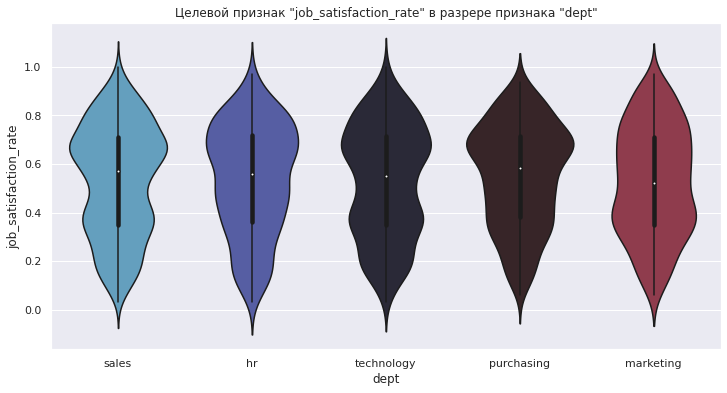

In [60]:
target_categorial('dept')

<font size="3">

**Вывод**
    
Распределение целевого признака `job_satisfaction_rate` однородно для всех департаментов компании.

---

<font size="3">
    
- **Признак `level`:**

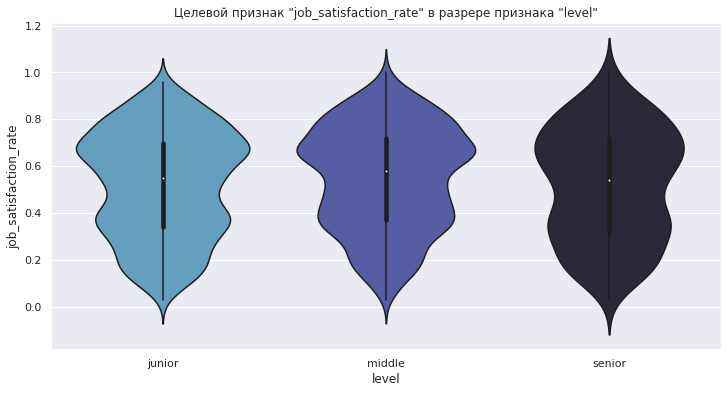

In [61]:
target_categorial('level')

<font size="3">

**Вывод**
    
Распределение целевого признака `job_satisfaction_rate` однородно для всех уровней занимаемой должности.

---

<font size="3">
    
- **Признак `workload`:**

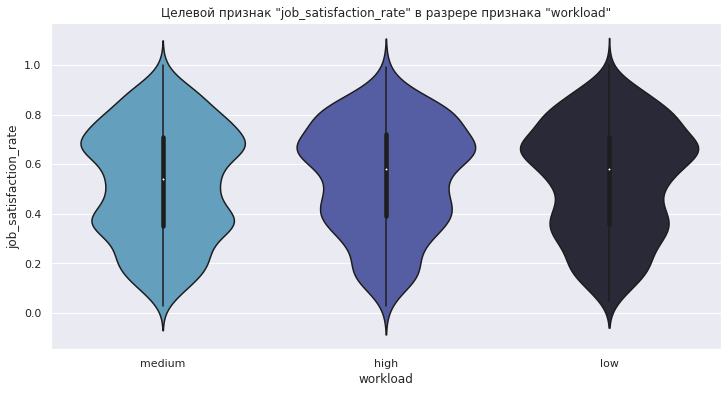

In [62]:
target_categorial('workload')

<font size="3">

**Вывод**
    
Распределение целевого признака `job_satisfaction_rate` однородно для всех уровней загруженности сотрудника.

---

<font size="3">
    
- **Признак `last_year_promo`:**

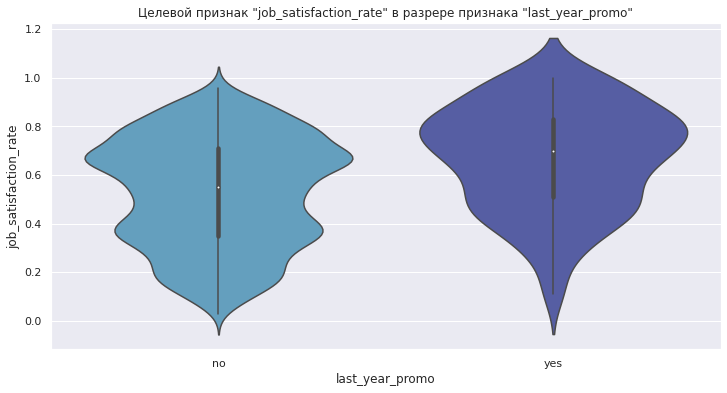

In [63]:
target_categorial('last_year_promo')

<font size="3">

**Вывод**
    
Сотрудникам, получившим повышение за последний год, соответствует больший уровень удовлетворённости работой.

---

<font size="3">
    
- **Признак `last_year_violations`:**

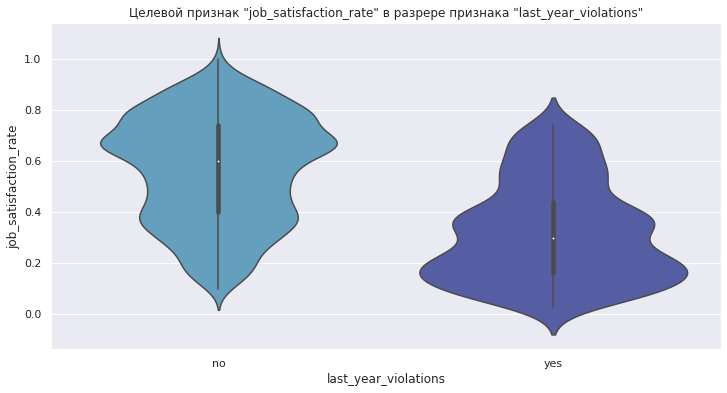

In [64]:
target_categorial('last_year_violations')

<font size="3">

**Вывод**
    
Сотрудникам, нарушавшим трудовой договор за последний год, соответствует меньший уровень удовлетворённости работой.

---

<font size="3">

**Вывод**
    
Проведён корреляционный анализ и выполнено графическое исследование сопряжённости целевого и входных признаков датафрейма `data_rate`.
    
Заметная зависимость с целевым признаком `job_satisfaction_rate` выявлена у признаков:
- `supervisor_evaluation`
- `last_year_violations` 

Мультиколлинеарность входных признаков отсутствует.

---

## Обучение моделей

<font size="3">
    
В данном шаге выберем лучшую модель для прогноза уровня удовлетворённости сотрудника на основе данных заказчика.
    
Для решения задачи обучим две модели: 
- `LinearRegression()`;
- `DecisionTreeRegressor()`
    
Выбор модели для проноза сделаем на основе метрики `SMAPE`.

---

<font size="3"> **Метрика SMAPE**
    
Напишем метрику `SMAPE` для оценки качества работы моделей.
    
Функцию с формулой расчёта метрики передадим в `make_scorer()` и сохраним в переменную `scorer`:

In [65]:
def smape(true, pred):
    smape = 100/len(
        true.to_numpy()) * np.sum(2 * np.abs(pred - true.to_numpy()) / (np.abs(true.to_numpy()) + np.abs(pred))
    )
    return smape

scorer = make_scorer(smape, greater_is_better=False)

<font size="3"> Для корректного расчёта метрики `SMAPE` отсортируем целевой признак `target_rate` аналогично датафрейму входных признаков `features_rate`. 
    
Результат запишем в переменную `target_sorted`.

In [66]:
target_sorted = pd.DataFrame()
for i in features_rate["id"].to_list():
    target_sorted=pd.concat([target_sorted, target_rate.loc[target_rate["id"]==i]], ignore_index=True)

<font size="3"> Проверим результат:

In [67]:
target_sorted.sample(5)

,id,job_satisfaction_rate
1910,940203,0.780
1411,915161,0.450
1306,765110,0.680
1749,162114,0.660
1150,502093,0.840


<font size="3"> 
    
**Вывод**

Целевой признак отсортирован, можно переходить к обучению моделей. 

---

### Модель `LinearRegression()`

<font size="3"> Напишем пайплайн для модели линейной регрессии:
    
- для работы с категориальными данными выберем кодировщики `OneHotEncoder` и `OrdinalEncoder`;
- пропуски в данных заполним константным значением `Unknown`;
- для масштабирования количественных признаков переберём несколько скейлеров; 
- зададим перебор заданных гиперпараметров методом `GridSearchCV`;
- качество модели оценим с помощью собственной метрики `SMAPE`.

In [68]:
X_train = data_rate.drop(['job_satisfaction_rate', 'id'], axis=1)
y_train = data_rate['job_satisfaction_rate']
X_test = features_rate.drop(['id'], axis=1)
y_test = target_sorted['job_satisfaction_rate']

# создаём списки с названиями признаков
ord_columns = ['dept', 'level', 'workload']
ohe_columns = ['last_year_promo', 'last_year_violations']
num_columns = X_train.select_dtypes(include='number').columns.tolist()

# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков + OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков + Ordinal-кодирование
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-900))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

parameters = {
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
}


grid_linreg = GridSearchCV(
    pipe_final, 
    param_grid=parameters,
    cv=5,
    scoring = scorer, 
    n_jobs=-1
)

<font size="3"> Обучим модель и выведем лучшие параметры:

In [69]:
grid_linreg.fit(X_train, y_train)

print('Лучшие параметры модели:\n\n', grid_linreg.best_params_)

Лучшие параметры модели:

 {'preprocessor__num': MinMaxScaler()}


<font size="3"> 
    
Выведем метрику модели:

In [70]:
y_pred_linreg = grid_linreg.predict(X_test)
print ('Метрика лучшей модели на кросс-валидационной выборке:', grid_linreg.best_score_)
print(f'Метрика SMAPE на тестовой выборке: {smape(y_test, y_pred_linreg):.2f}')

Метрика лучшей модели на кросс-валидационной выборке: -26.85403327978176
Метрика SMAPE на тестовой выборке: 25.31


<font size="3"> 
    
**Вывод**
    
На данном этапе исследования написан пайплайн для модели линейной регрессии с методом оценки модели с помощью метрики `SMAPE`.
    
Лучше всего из заданных в гиперпараметрах скейлеров себя показал метод метод масштабирования количественных данных `MinMaxScaler()`.
    
Результат работы модели неудовлетворительный: 
- Метрика лучшей модели на кросс-валидационной выборке: 26.85
- Метрика SMAPE на тестовой выборке: 25.31
    
Данные показатели метрики не соответстуют критериям успеха: SMAPE ≤ 15. 

---

### Модель `DecisionTreeRegressor()`

<font size="3"> Напишем пайплайн для дерева регрессии:
    
- для работы с категориальными данными выберем кодировщики `OneHotEncoder` и `OrdinalEncoder`;
- пропуски в данных заполним константным значением `Unknown`;
- масштабирование количественных данных выполним с помощью `MinMaxScaler()`; 
- подбор гиперпараметров модели выполним с помощью `OptunaSearchCV`;
- качество модели оценим с помощью собственной метрики `SMAPE`.

In [71]:
RANDOM_STATE = 42

X_train = data_rate.drop(['job_satisfaction_rate', 'id'], axis=1)
y_train = data_rate['job_satisfaction_rate']
X_test = features_rate.drop(['id'], axis=1)
y_test = target_sorted['job_satisfaction_rate']

# создаём списки с названиями признаков
ord_columns = ['dept', 'level', 'workload']
ohe_columns = ['last_year_promo', 'last_year_violations']
num_columns = X_train.select_dtypes(include='number').columns.tolist()

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков + Ordinal-кодирование
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-900))
    ]
)

# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков + OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ord', ord_pipe, ord_columns),
     ('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

parameters = {
    'models__max_depth': distributions.IntDistribution(2, 35),
    'models__min_samples_split': distributions.IntDistribution(2, 20)
}

oscv_tree_reg = OptunaSearchCV(
    pipe_final,
    parameters,
    scoring=scorer,
    cv=5,
    n_trials=100,
    random_state=RANDOM_STATE 
)

/tmp/ipykernel_541/397123031.py:48: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_tree_reg = OptunaSearchCV(


<font size="3"> Выведем лучшие параметры модели:

In [72]:
oscv_tree_reg.fit(X_train, y_train)

print('Лучшие параметры модели:\n\n', oscv_tree_reg.best_params_)

[I 2024-02-29 12:33:15,936] A new study created in memory with name: no-name-d2bdcd28-36ee-4c95-940d-689c3eadb8b2
[I 2024-02-29 12:33:16,095] Trial 0 finished with value: -14.90238740743413 and parameters: {'models__max_depth': 17, 'models__min_samples_split': 17}. Best is trial 0 with value: -14.90238740743413.
[I 2024-02-29 12:33:16,246] Trial 1 finished with value: -21.369363341096836 and parameters: {'models__max_depth': 4, 'models__min_samples_split': 8}. Best is trial 0 with value: -14.90238740743413.
[I 2024-02-29 12:33:16,411] Trial 2 finished with value: -14.80126592950744 and parameters: {'models__max_depth': 18, 'models__min_samples_split': 7}. Best is trial 2 with value: -14.80126592950744.
[I 2024-02-29 12:33:16,579] Trial 3 finished with value: -16.122710288677332 and parameters: {'models__max_depth': 9, 'models__min_samples_split': 5}. Best is trial 2 with value: -14.80126592950744.
[I 2024-02-29 12:33:16,724] Trial 4 finished with value: -17.71883569153125 and parameter

Лучшие параметры модели:

 {'models__max_depth': 28, 'models__min_samples_split': 14}


<font size="3"> Выведем метрику модели: 

In [73]:
y_pred_tree_reg = oscv_tree_reg.predict(X_test)
print ('Метрика лучшей модели на кросс-валидационной выборке:', oscv_tree_reg.best_score_)
print(f'Метрика SMAPE на тестовой выборке: {smape(y_test, y_pred_tree_reg):.2f}')

Метрика лучшей модели на кросс-валидационной выборке: -14.720301918857235
Метрика SMAPE на тестовой выборке: 13.76


<font size="3"> 
    
**Вывод**
    
На данном этапе исследования написан пайплайн для модели дерева регрессии с методом оценки модели с помощью метрики `SMAPE`.
        
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 14.72
- Метрика SMAPE на тестовой выборке: 13.76   

### Выбор лучшей модели

<font size="3"> 
    
Модель дерево решений для регрессии показала лучший результат при прогнозе уровня удовлетворённости сотрудника. 
    
Полученная метрика симметричного среднего абсолютного процентного отклонения удовлетворяет заданному критерию ≤ 15, выбираем данную модель для получения прогноза удовлетворённости сотрудника работой.

---

## Предсказание увольнения сотрудника из компании

<font size="3"> Вторая задача исследования - построение модели, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

---

### Чтение данных

<font size="3">

- **Датасет `train_quit`**

<font size="3"> Считаем тренировочную выборку с характеристиками сотрудников компании и целевым признаком-индикатором увольнения сотрудников и сохраним в переменную `data_quit`:

In [74]:
try:
    data_quit = pd.read_csv('/datasets/train_quit.csv')
except:
    data_quit = pd.read_csv('/Users/kasper/Documents/Projects/Сборный-2 HR/train_quit.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `data_quit` на экран:

In [75]:
data_quit.head(20)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no
5,699916,sales,junior,low,1,no,yes,3,18000,yes
6,417070,technology,middle,medium,8,no,no,2,44400,no
7,165489,sales,middle,low,4,no,no,5,19200,no
8,996399,marketing,middle,low,7,no,no,4,25200,no
9,613206,technology,middle,medium,2,no,no,3,45600,yes


<font size="3">

- **Датасет `test_features`**

<font size="3"> Считаем тестовую выборку с входными признаками и сохраним в переменную `features_quit`:

In [76]:
try:
    features_quit = pd.read_csv('/datasets/test_features.csv')
except:
    features_quit = pd.read_csv('/Users/kasper/Documents/Projects/Сборный-2 HR/test_features.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `features_quit` на экран:

In [77]:
features_quit.head(20)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
5,429973,purchasing,middle,medium,6,no,no,3,42000
6,850699,technology,junior,medium,3,no,no,3,26400
7,500791,sales,middle,high,9,no,no,4,49200
8,767867,marketing,middle,high,3,no,yes,4,62400
9,937235,sales,junior,medium,1,no,yes,3,26400


<font size="3">

- **Датасет `test_target_quit`**

<font size="3"> Считаем датасет с входным признаком-индикатором увольнения сотрудников и сохраним в переменную `target_quit`:

In [78]:
try:
    target_quit = pd.read_csv('/datasets/test_target_quit.csv')
except:
    target_quit = pd.read_csv('/Users/kasper/Documents/Projects/Сборный-2 HR/test_target_quit.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `target_quit` на экран:

In [79]:
target_quit.head(20)

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes
5,223063,no
6,810370,no
7,998900,no
8,578329,no
9,648850,no


---

### Изучение датафреймов

<font size="3">
    
Изучим структуру и полноту полученных датафреймов.
    
- **Датафрейм `data_quit`**

In [80]:
data_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


<Axes: >

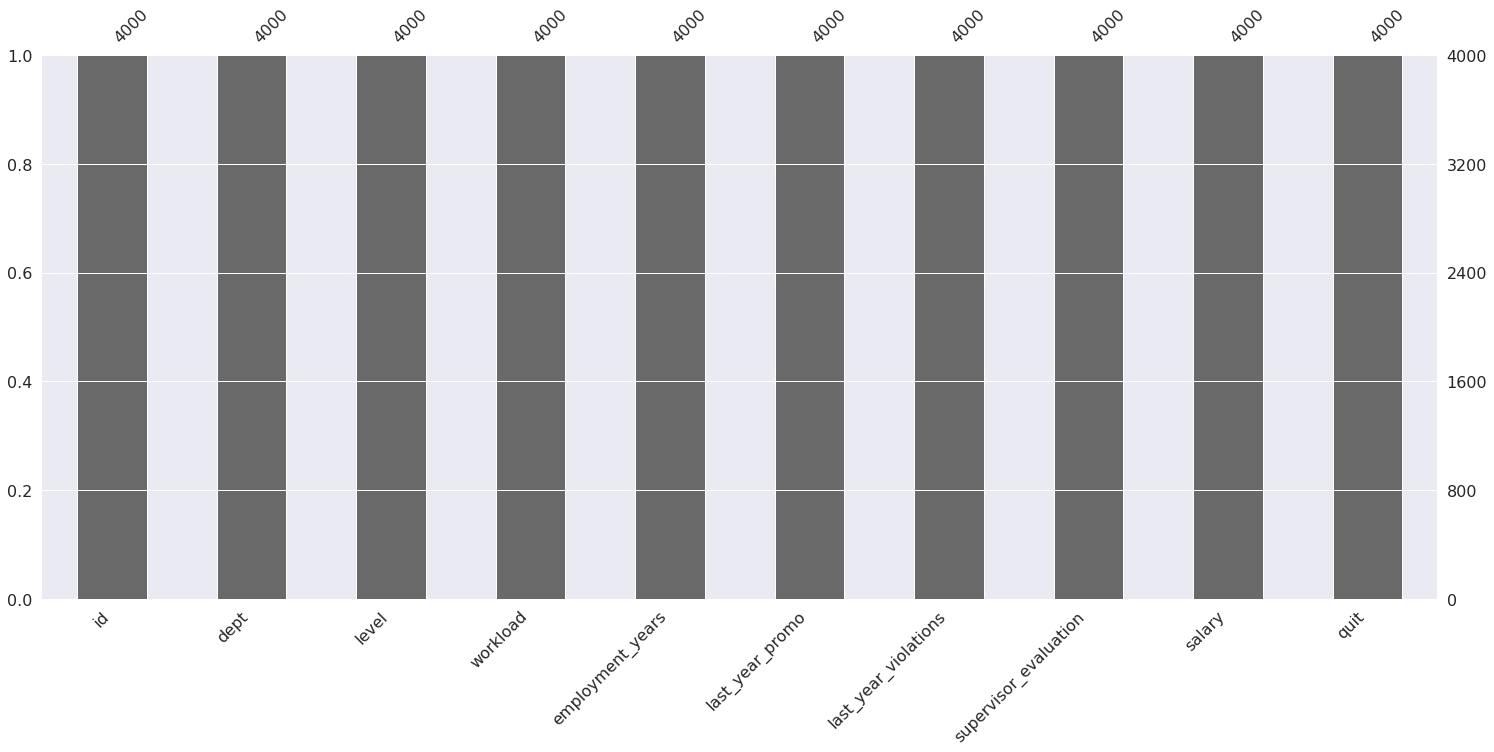

In [81]:
msno.bar(data_quit)

<font size="3">

- **Датафрейм `features_quit`**

In [82]:
features_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


<Axes: >

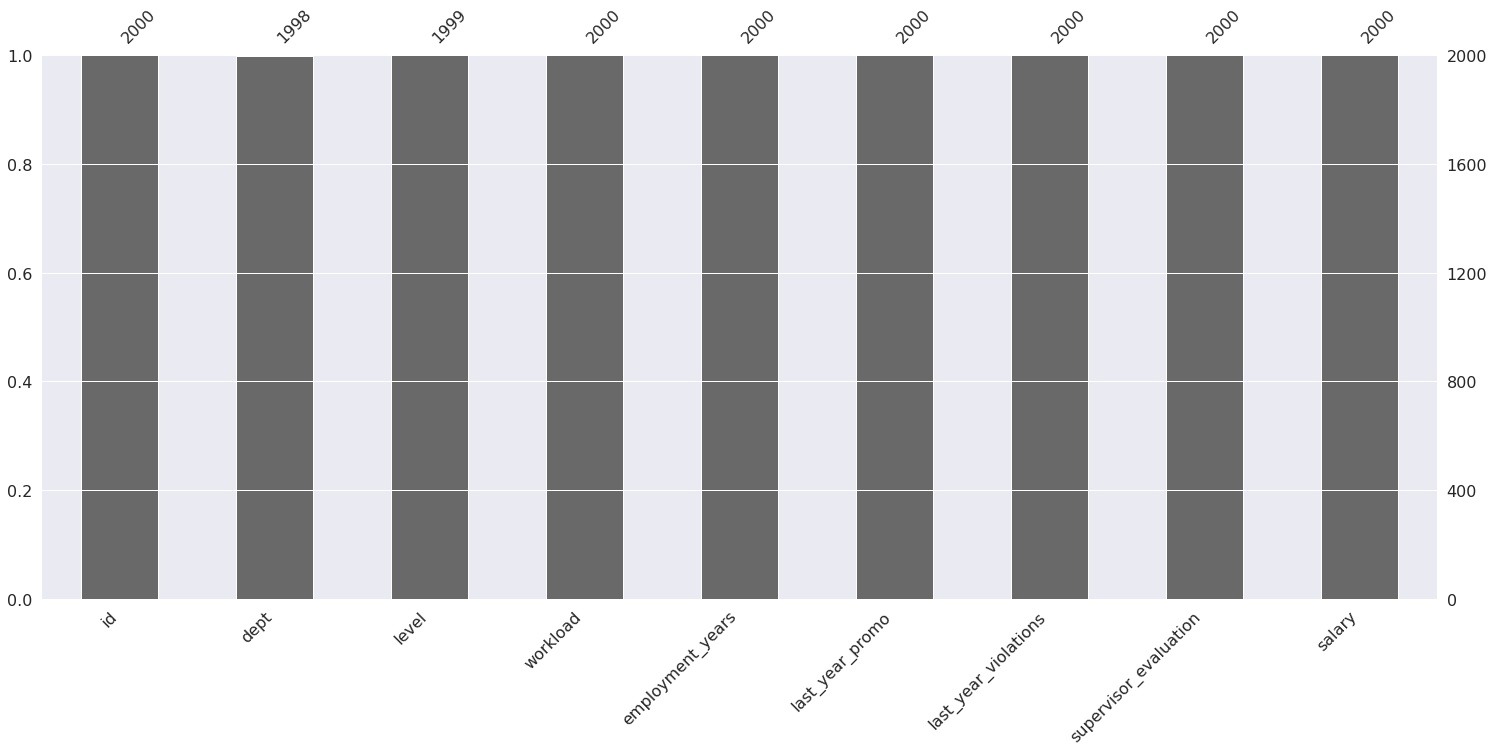

In [83]:
msno.bar(features_quit)

<font size="3">

- **Датафрейм `target_quit`**

In [84]:
target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


<Axes: >

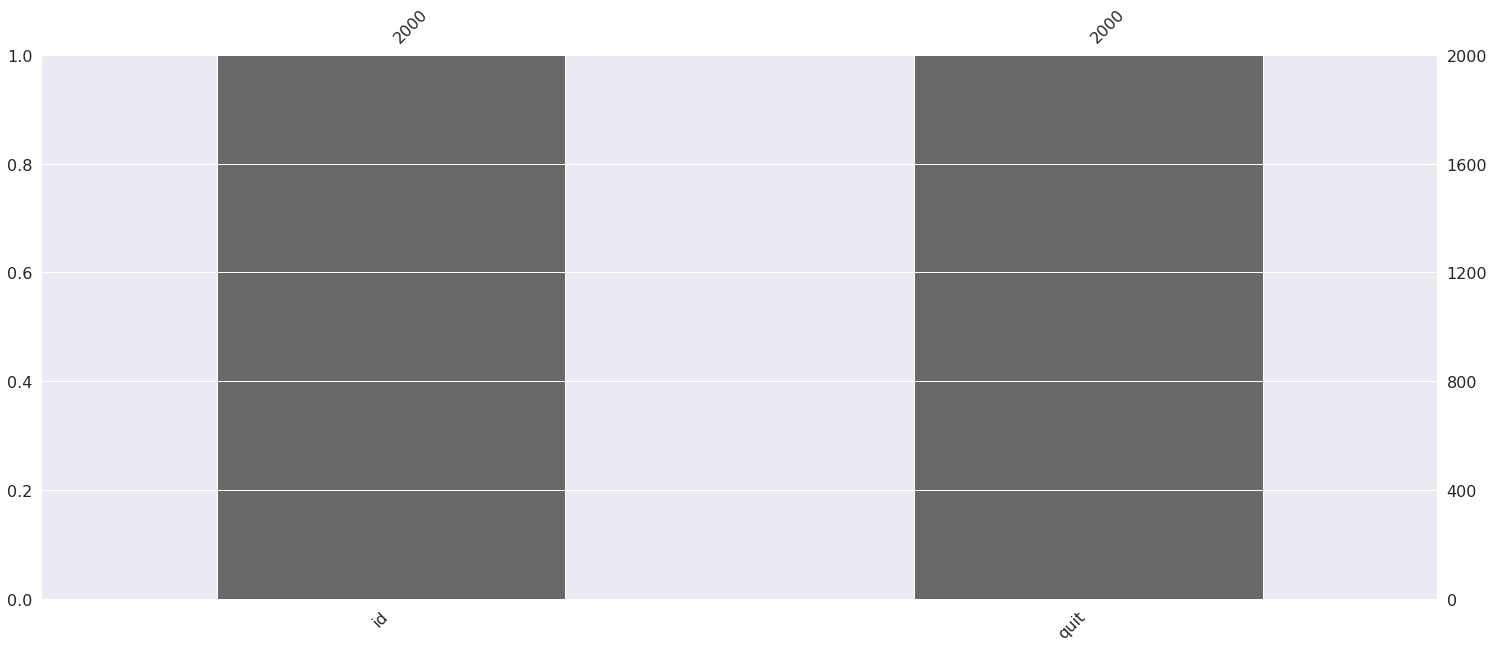

In [85]:
msno.bar(target_quit)

<font size="3">
    
**Вывод:**

Полученные датафреймы содержат следующие данные:

- **датафрейм `data_quit`:**
  * `id` — уникальный идентификатор сотрудника;
  * `dept` — отдел, в котором работает сотрудник;
  * `level` — уровень занимаемой должности;
  * `workload` — уровень загруженности сотрудника;
  * `employment_years` — длительность работы в компании (в годах);
  * `last_year_promo` — показывает, было ли повышение за последний год;
  * `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
  * `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
  * `salary` — ежемесячная зарплата сотрудника;
  * `quit` - увольнение сотрудника из компании - целевой признак.

---
    

- **датафреймы `features_quit`:**
  * `id` — уникальный идентификатор сотрудника;
  * `dept` — отдел, в котором работает сотрудник;
  * `level` — уровень занимаемой должности;
  * `workload` — уровень загруженности сотрудника;
  * `employment_years` — длительность работы в компании (в годах);
  * `last_year_promo` — показывает, было ли повышение за последний год;
  * `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
  * `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
  * `salary` — ежемесячная зарплата сотрудника.
  
---

- **датафреймы `target_quit`:**
  * `id` — уникальный идентификатор сотрудника;
  * `quit` - увольнение сотрудника из компании - целевой признак.
    
---

Предварительно можно утверждать, что данных достаточно для проведения анализа. В датасетах имеются пропущенные значения.

Столбцы датафреймов именованы корректно, стоит подробнее изучить тип имеющихся данных, а также в данных могут присутствовать дубликаты.

Необходима предобработка данных.

---

## Предобработка данных

### Тип данных

<font size="3">
    
Убедимся, что в датафреймах корретный тип данных.
    
- **датафрейм `data_quit`:**

In [86]:
data_quit.dtypes

id                        int64
dept                     object
level                    object
workload                 object
employment_years          int64
last_year_promo          object
last_year_violations     object
supervisor_evaluation     int64
salary                    int64
quit                     object
dtype: object

<font size="3"> Проверим результат:

In [87]:
data_quit['quit'].value_counts()

no     2872
yes    1128
Name: quit, dtype: int64

<font size="3"> 
    
- **датафрейм `features_quit`:**

In [88]:
features_quit.dtypes

id                        int64
dept                     object
level                    object
workload                 object
employment_years          int64
last_year_promo          object
last_year_violations     object
supervisor_evaluation     int64
salary                    int64
dtype: object

<font size="3"> 
    
- **датафрейм `target_quit`:**

In [89]:
target_quit.dtypes

id       int64
quit    object
dtype: object

<font size="3"> Проверим результат:

In [90]:
target_quit['quit'].value_counts()

no     1436
yes     564
Name: quit, dtype: int64

<font size="3">

---
**Вывод**

Все столбцы в датафреймах содержат корректный тип данных: количественные столбцы имеют тип `float64` и `int64`, категориальные - тип `object`.

---

### Проверка пропусков

<font size="3"> Гистограммы `msno` показали наличие пропущенных значений в датафрейме `features_quit`, изучим подробнее:

In [91]:
features_quit.isna().sum()

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

<font size="3">

---
**Вывод**


Пропущенные значения обнаружены в категориальных признаках `dept` и `level`. 
    
Заполнение пропусков наиболее часто встречающимся значением не гарантирует того, что данные будут восстановлены корректно. Заполним подобные значения категорией-заглушкой, чтобы для построения прогноза модель использовала только достоверные данные.
    
Пропущенные значения обработаем в шаге пайплайна по выбранному алгоритму.

---

### Проверка явных дубликатов

<font size="3">
    
Проверим наличие явных дубликатов в датафреймах.

- **датафрейм `data_quit`:**

In [92]:
data_quit.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

<font size="3">
    
- **датафрейм `features_quit`:**

In [93]:
features_quit.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

<font size="3">
    
- **датафрейм `target_quit`:**

In [94]:
target_quit.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

---

### Проверка неявных дубликатов

<font size="3">
    
Проверим категориальные столбцы датафреймов на наличие неявных дубликатов.

<font size="3">

- **датафрейм `data_quit`**
    
Столбец `dept`:

In [95]:
data_quit['dept'].value_counts()

sales         1438
technology     928
purchasing     588
marketing      582
hr             464
Name: dept, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `level`:

In [96]:
data_quit['level'].value_counts()

junior    1949
middle    1694
sinior     357
Name: level, dtype: int64

<font size="3"> Переименуем значение "sinior" в "senior".

In [97]:
data_quit['level'] = data_quit['level'].replace(
    ['sinior'], 
    'senior', 
    regex=True
)

<font size="3"> Проверим результат:

In [98]:
data_quit['level'].value_counts()

junior    1949
middle    1694
senior     357
Name: level, dtype: int64

<font size="3"> Категории именованы корректно, неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `workload`:

In [99]:
data_quit['workload'].value_counts()

medium    2118
low       1208
high       674
Name: workload, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `last_year_promo`:

In [100]:
data_quit['last_year_promo'].value_counts()

no     3887
yes     113
Name: last_year_promo, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3"> Столбец `last_year_violations`:

In [101]:
data_quit['last_year_violations'].value_counts()

no     3455
yes     545
Name: last_year_violations, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

<font size="3">

- **датафрейм `features_quit`**
    
Столбец `dept`:

In [102]:
features_quit['dept'].value_counts()

sales         763
technology    455
marketing     279
purchasing    273
hr            227
                1
Name: dept, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `level`:

In [103]:
features_quit['level'].value_counts()

junior    974
middle    854
sinior    171
Name: level, dtype: int64

<font size="3"> Переименуем значение "sinior" в "senior".

In [104]:
features_quit['level'] = features_quit['level'].replace(
    ['sinior'], 
    'senior', 
    regex=True
)

<font size="3"> Проверим результат:

In [105]:
features_quit['level'].value_counts()

junior    974
middle    854
senior    171
Name: level, dtype: int64

<font size="3"> Категории именованы корректно, неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `workload`:

In [106]:
features_quit['workload'].value_counts()

medium    1043
low        593
high       363
             1
Name: workload, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `last_year_promo`:

In [107]:
features_quit['last_year_promo'].value_counts()

no     1937
yes      63
Name: last_year_promo, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---

<font size="3">
    
Столбец `last_year_violations`:

In [108]:
features_quit['last_year_violations'].value_counts()

no     1738
yes     262
Name: last_year_violations, dtype: int64

<font size="3"> Неявные дубликаты отсутствуют.

---
<font size="3">

**Вывод**

Для корректного проведения исследования выполнена предобработка данных:

- Проверены типы данных;
- Выбран алгоритм обработки пропусков в датафреймах;
- Проверены и обработаны дубликаты в датафреймах, в том числе и неявные.

---

## Исследовательский анализ данных

<font size="3"> Проведём исследовательский анализ всех признаков датафрейма `data_quit`.

### Количественные признаки


<font size="3"> Используем написанную ранее функцию `visuals`, которая построит гистограмму распределения, коробчатую диаграмму и выведет метод `describe()`:

<font size="3">
    
- **Признак `employment_years`:**

count   4,000.000
mean        3.701
std         2.542
min         1.000
25%         2.000
50%         3.000
75%         6.000
max        10.000
Name: employment_years, dtype: float64

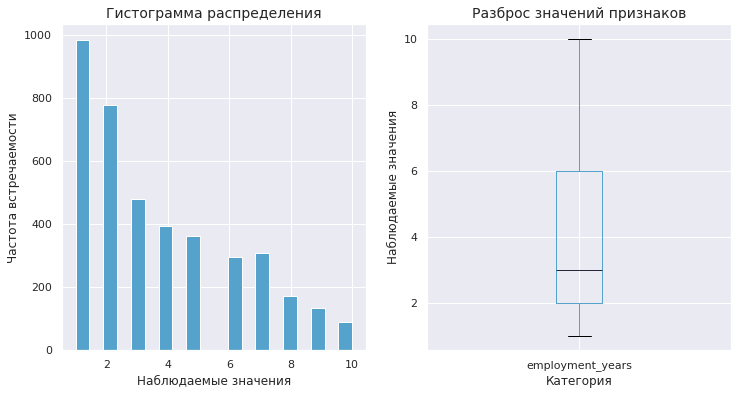

In [109]:
visuals(data_quit, 'employment_years')

<font size="3">
    
**Вывод:**
    
Признак `employment_years` отображает длительность работы сотрудника в компании в годах. 
    
Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 2 до 6 лет со средним значением в 3.7.

Выбросы и аномалии в данных отсутствуют.

---
<font size="3">
    
- **Признак `supervisor_evaluation`:**

count   4,000.000
mean        3.475
std         1.004
min         1.000
25%         3.000
50%         4.000
75%         4.000
max         5.000
Name: supervisor_evaluation, dtype: float64

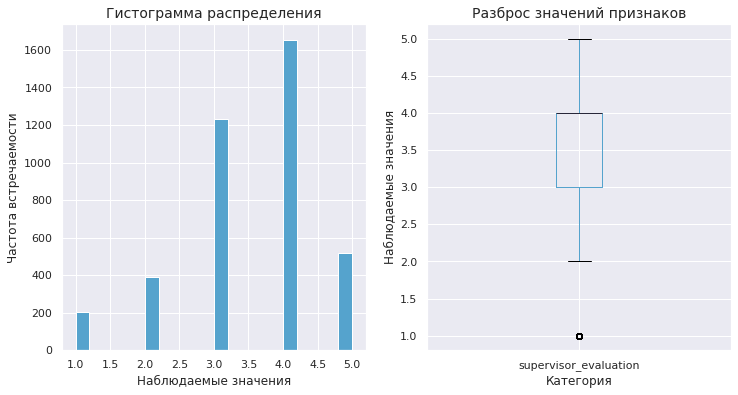

In [110]:
visuals(data_quit, 'supervisor_evaluation')

<font size="3">
    
**Вывод**

Признак `supervisor_evaluation` отображает оценку качества работы сотрудника, которую дал его руководитель. 
    
Распределение признака асимметрично влево, большинство значений располагается в промежутке от 3 до 4 со средним значением в 3.5 баллов.

Выбросы и аномалии в данных отсутствуют.

---

<font size="3">
    
- **Признак `salary`:**

count    4,000.000
mean    33,805.800
std     15,152.415
min     12,000.000
25%     22,800.000
50%     30,000.000
75%     43,200.000
max     96,000.000
Name: salary, dtype: float64

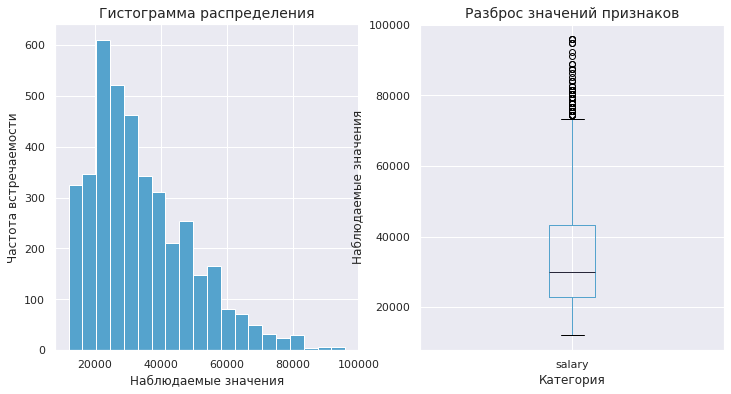

In [111]:
visuals(data_quit, 'salary')

<font size="3">
    
**Вывод:**
    
Признак `salary` отображает ежемесячную заработную плату сотрудника. 
    
Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 23000 до 43000 со средним значением в 34000 рублей.

Выбросы и аномалии в данных отсутствуют.

---

### Категориальные признаки

<font size="3">
    
Изучим категориальные признаки датафрейма `data_quit`.

Используем функцию `cat_visuals()`, которая визуализирует признак с помощью столбчатой гистограммы.

<font size="3">
    
- **Признак `dept`:**

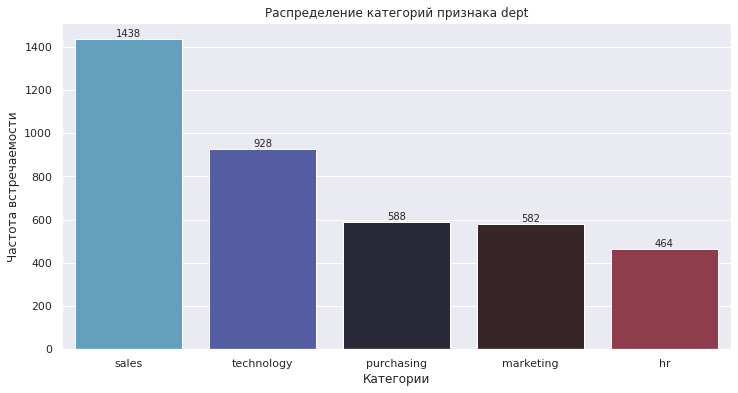

In [112]:
cat_visuals(data_quit, 'dept')

<font size="3">
    
**Вывод**

Признак `dept` представлен категориями: 
- «sales»
- «technology»
- «purchasing»
- «marketing»
- «hr»

В выборке преобладает департамент «sales».

---

<font size="3">
    
- **Признак `level`:**

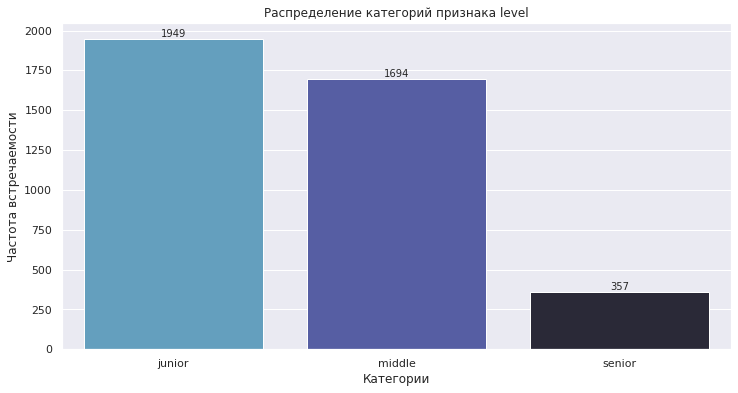

In [113]:
cat_visuals(data_quit, 'level')

<font size="3">
    
**Вывод**

Признак `level` представлен категориями: 
- «junior»
- «middle»
- «senior»

В выборке преобладает категория «junior».

---

<font size="3">
    
- **Признак `workload`:**

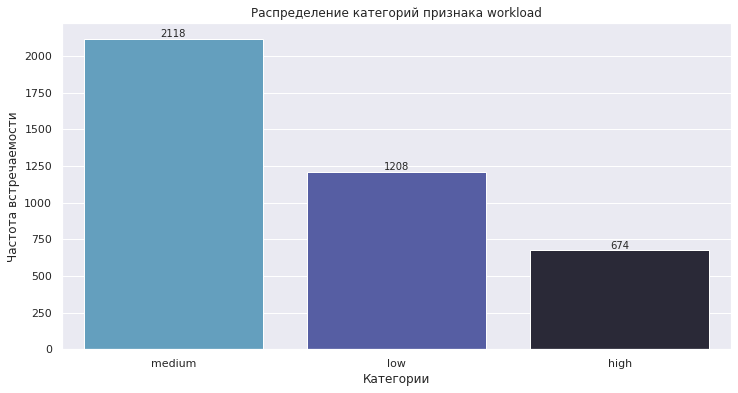

In [114]:
cat_visuals(data_quit, 'workload')

<font size="3">
    
**Вывод**

Признак `workload` представлен категориями: 
- «low»
- «medium»
- «high»

В выборке преобладает категория «medium».

---

<font size="3">
    
- **Признак `last_year_promo`:**

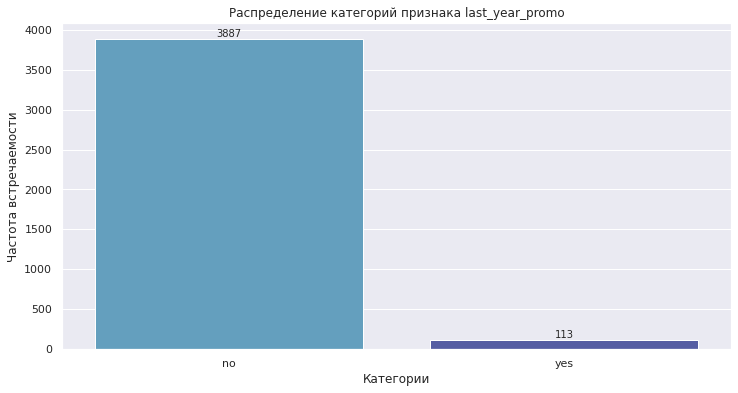

In [115]:
cat_visuals(data_quit, 'last_year_promo')

<font size="3">
    
**Вывод**

Признак `last_year_promo` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

---

<font size="3">
    
- **Признак `last_year_violations`:**

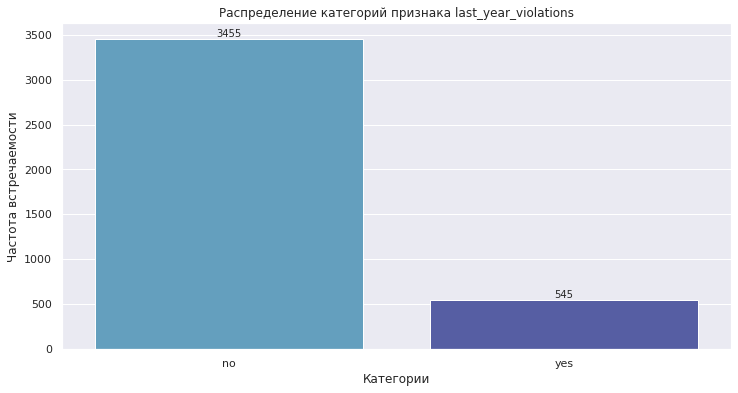

In [116]:
cat_visuals(data_quit, 'last_year_violations')

<font size="3">
    
**Вывод**

Признак `last_year_violations` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

---

<font size="3">
    
- **Целевой признак `quit`:**

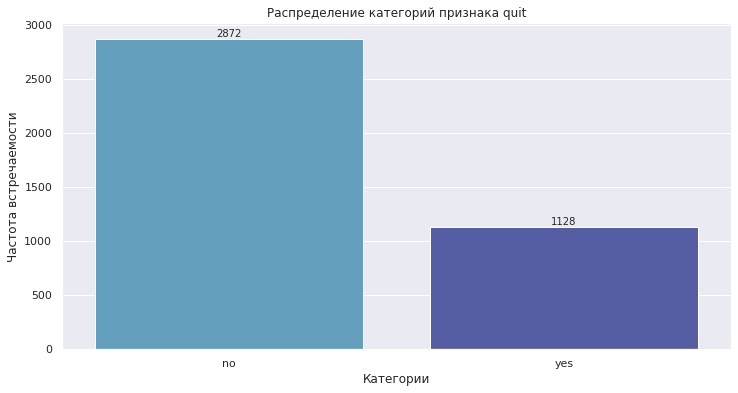

In [117]:
cat_visuals(data_quit, 'quit')

<font size="3">
    
**Вывод**

Целевой признак `quit` представлен категориями: 
- «1»
- «0»

В выборке преобладает категория «0» - не уволился.

---
<font size="3">

**Вывод**

В датафрейме `data_quit` 3 количественных и 6 категориальных признаков.
    
Выбросов и аномалий в данных не обнаружено.

---

## Корреляционный анализ

<font size="3"> Проведём корреляционный анализ признаков датафрейма `data_quit`. 

Признак `quit` - целевой, изучим взаимосвязь входных признаков с целевым, а также выявим мультиколлинеарность признакового описания при его наличии.

<font size="3"> Корреляцию признаков рассмотрим с помощью матрицы корреляций `phik_matrix()`:

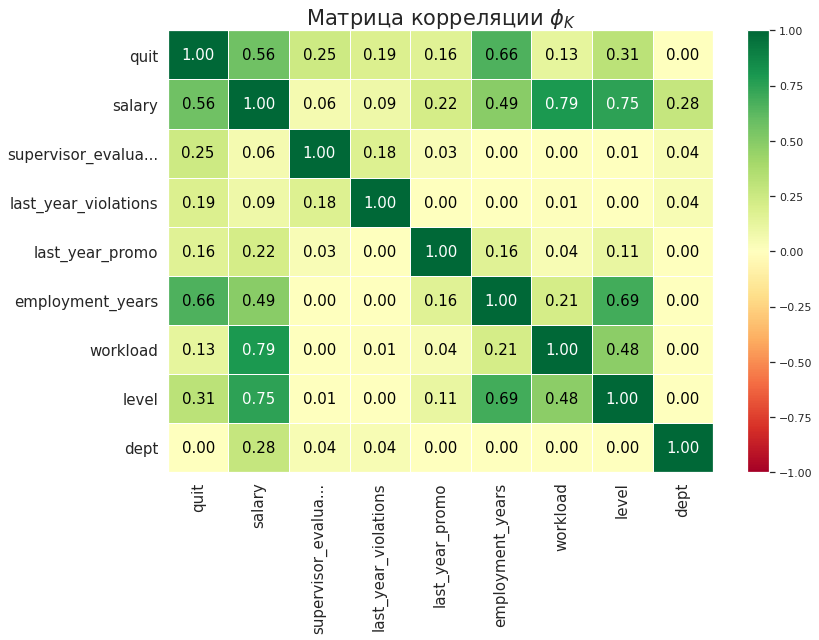

In [118]:
phik_matrix(data_quit.loc[:,'dept' : 'quit'])

<font size="3">

**Вывод**

Заметная зависимость с целевым признаком `quit` выявлена у признаков: 
- `employment_years`
- `salary`

У остальных входных признаков умеренная либо слабая зависимость с целевым.

Мультиколлинеарность входных признаков не выявлена.

---
    
### Целевой признак

<font size="3"> Целевым в датафрейме `data_quit` является категориальный признак `quit`.
    
    
Рассмотрим сопряжённость целевого признака и всеми признаками датафрейма.

---

<font size="3">

#### Количественные признаки
    
Напишем функцию `target_num()` для отображения распределения количественных признаков датафрейма в разрезе целевого признака `quit`.

In [119]:
def target_num(col):
    fig, axes = plt.subplots(figsize=(12,6))
    
    sns.violinplot(data=data_quit, x='quit', y=col, ax=axes)
    
    plt.title("Распределение признака " + col + " в разрезе увольнения сотрудника из компании")
    plt.xlabel("увольнение сотрудника из компании")
    plt.ylabel("признак " + col);

<font size="3">
    
- **Признак `employment_years`:**

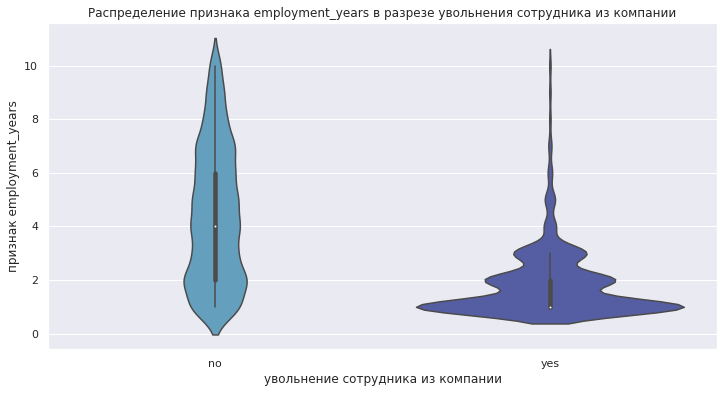

In [120]:
target_num('employment_years')

<font size="3">

**Вывод**
    
Можно отметить, что сотрудникам категории `1` (уволились) соответствует меньшее количество отработанных лет: от 1 до 3.
    
Доля уволившихся среди сотрудников, проработавших от 4 и более лет в компании, значительно ниже.

---

<font size="3">
    
- **Признак `supervisor_evaluation`:**

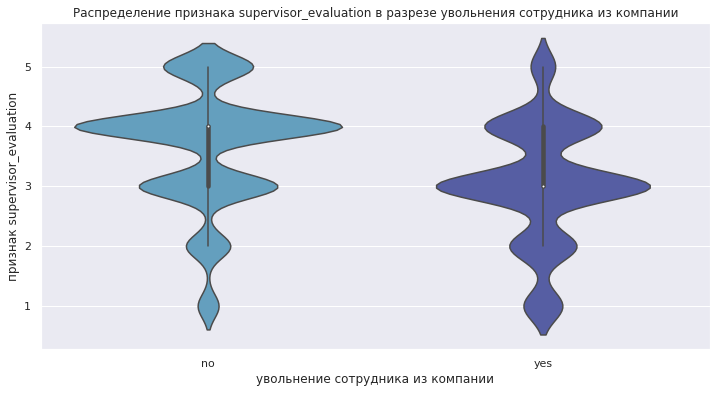

In [121]:
target_num('supervisor_evaluation')

<font size="3">

**Вывод**
    
Можно отметить, что среди сотрудников, получивших низкую оценку от руководителя, доля уволившихся значительно выше, чем среди сотрудников, получивших  оценки 4 и 5.

---

<font size="3">
    
- **Признак `salary`:**

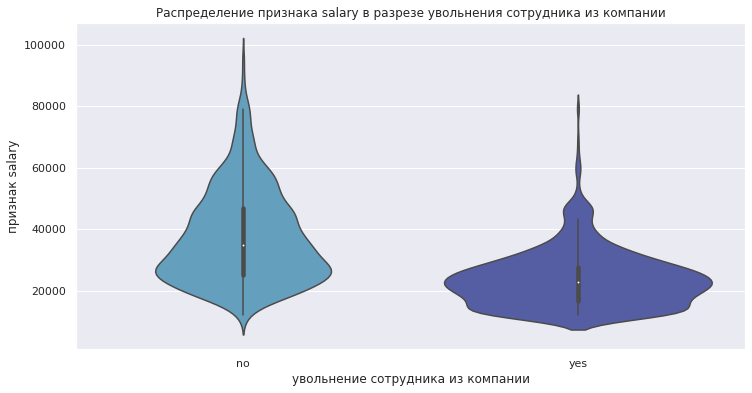

In [122]:
target_num('salary')

<font size="3">

**Вывод**
    
Можно отметить, что сотрудникам категории `1` (уволились) соответствует меньший уровень заработной платы: от 10000 до 30000 рублей.
    
Доля уволившихся среди сотрудников, имеющих более высокий уровень заработной платы (от 40000 рублей), значительно ниже.

---

<font size="3">
    
#### Категориальные признаки
    
Напишем функцию `target_cat()` для визуализации сопряжённости категориальных признаков датафрейма с целевым признаком `quit`.
    
Дополнительно выведем общее количество сотрудников в каждой категории признака и долю уволившихся сотрудников.

In [123]:
def target_cat (cat):
    headcount = data_quit.groupby([cat, 'quit'])['quit'].agg(['count'])
    display(headcount)
    
    quit_portion = pd.DataFrame(data_quit.groupby(cat)['quit'].value_counts(normalize=True))
    display(quit_portion)
    
    fig, ax = plt.subplots(figsize=(12,6))

    pd.crosstab(
        data_quit['quit'], 
        data_quit[cat]
    ).plot.bar(rot = 0, ax=ax)
    
    plt.title("Сопряжённость признаков quit и " + cat)
    plt.xlabel("увольнение сотрудника из компании")
    plt.ylabel("частота встречаемости"); 

<font size="3">
    
- **Признак `dept`:**

count
dept       quit       
hr         no      348
           yes     116
marketing  no      419
           yes     163
purchasing no      422
           yes     166
sales      no     1031
           yes     407
technology no      652
           yes     276

quit
dept       quit      
hr         no   0.750
           yes  0.250
marketing  no   0.720
           yes  0.280
purchasing no   0.718
           yes  0.282
sales      no   0.717
           yes  0.283
technology no   0.703
           yes  0.297

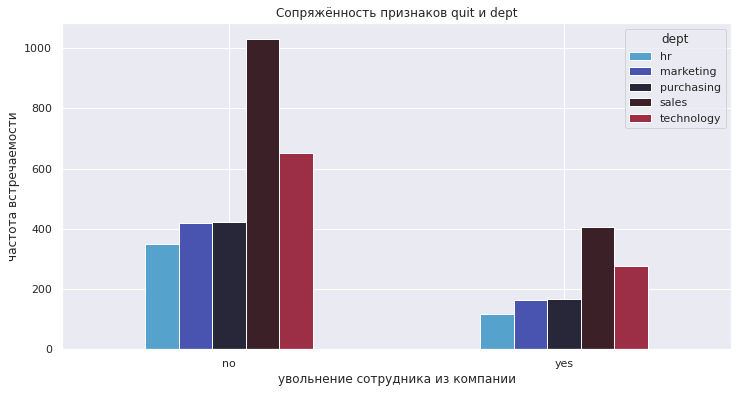

In [124]:
target_cat('dept')

<font size="3">

**Вывод**
        
Доля уволившихся сотрудников:
- **HR**:
    - в отделе 464 сотрудника, из них уволилось 116, доля уволившихся - `0.250`;
- **marketing**:
    - в отделе 582 сотрудника, из них уволилось 163, доля уволившихся - `0.280`;
- **purchasing**:
    - в отделе 588 сотрудников, из них уволилось 166, доля уволившихся - `0.282`;  
- **sales**:
    - в отделе 1438 сотрудников, из них уволилось 407, доля уволившихся - `0.283`;
- **technology**:
    - в отделе 928 сотрудников, из них уволилось 276, доля уволившихся - `0.297`
    
Наибольшая доля уволившихся сотрудников в департаменте **technology**.

---

<font size="3">
    
- **Признак `level`:**

count
level  quit       
junior no      946
       yes    1003
middle no     1586
       yes     108
senior no      340
       yes      17

quit
level  quit      
junior yes  0.515
       no   0.485
middle no   0.936
       yes  0.064
senior no   0.952
       yes  0.048

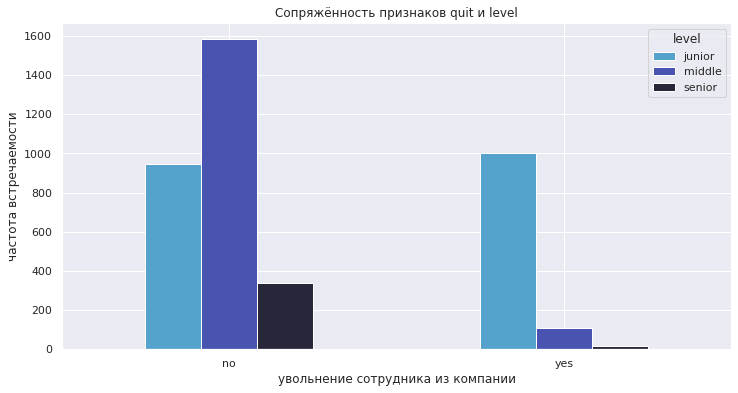

In [125]:
target_cat('level')

<font size="3">

**Вывод**
            
Доля уволившихся сотрудников по уровню занимаемой должности:
- **junior**:
    - данный уровень должности имеют 1949 сотрудников, из них уволилось 1003, доля уволившихся - `0.515`;
- **middle**:
    - данный уровень должности имеют 1694 сотрудников, из них уволилось 108, доля уволившихся - `0.064`;
- **senior**:
    - данный уровень должности имеют 357 сотрудников, из них уволилось 17, доля уволившихся - `0.048`;
    
Наибольшая доля уволившихся сотрудников  по уровню занимаемой должности в сегменте **junior**.

---

<font size="3">
    
- **Признак `workload`:**

count
workload quit       
high     no      553
         yes     121
low      no      689
         yes     519
medium   no     1630
         yes     488

quit
workload quit      
high     no   0.820
         yes  0.180
low      no   0.570
         yes  0.430
medium   no   0.770
         yes  0.230

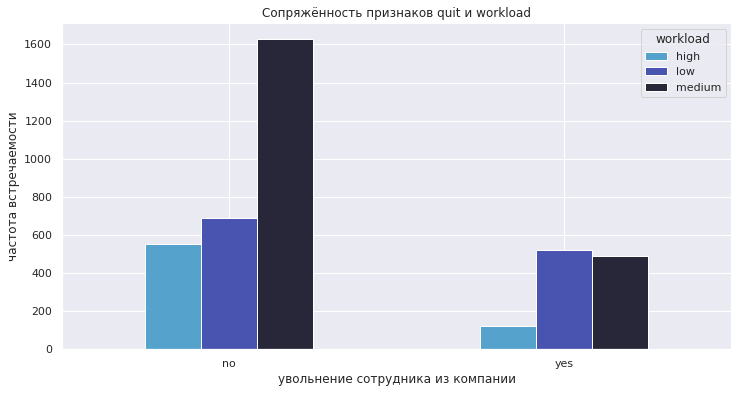

In [126]:
target_cat('workload')

<font size="3">

**Вывод**
 
Доля уволившихся сотрудников по уровню загруженности сотрудника:
- **low**:
    - данный уровень загруженности имеют 1208 сотрудников, из них уволилось 519, доля уволившихся - `0.430`;
- **middle**:
    - данный уровень загруженности имеют 2118 сотрудников, из них уволилось 488, доля уволившихся - `0.230`;
- **high**:
    - данный уровень загруженности имеют 674 сотрудников, из них уволилось 121, доля уволившихся - `0.180`;
    
Наибольшая доля уволившихся сотрудников  по уровню загруженности сотрудника в сегменте **low**.

---

<font size="3">
    
- **Признак `last_year_promo`:**

count
last_year_promo quit       
no              no     2760
                yes    1127
yes             no      112
                yes       1

quit
last_year_promo quit      
no              no   0.710
                yes  0.290
yes             no   0.991
                yes  0.009

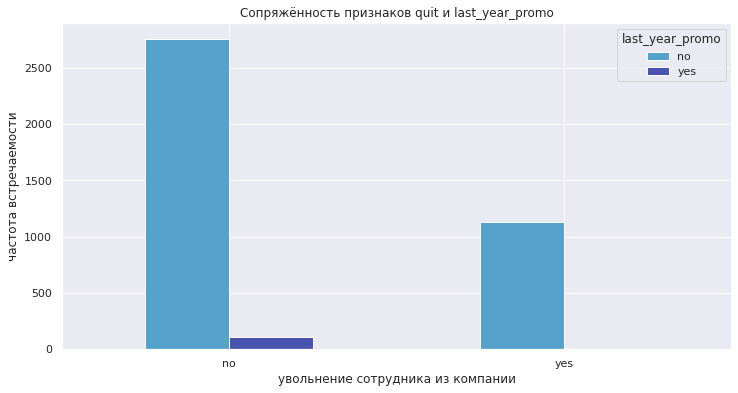

In [127]:
target_cat('last_year_promo')

<font size="3">

**Вывод**
    
Доля уволившихся сотрудников по наличию повышения за последний год:
- **no**:
    - не получили повышение 3887 сотрудников, из них уволилось 1127, доля уволившихся - `0.290`;
- **yes**:
    - получили повышение 113 сотрудников, из них уволилось 1, доля уволившихся - `0.009`
    
Наибольшая доля уволившихся сотрудников по наличию повышения за последний год в сегменте **no**.

---

<font size="3">
    
- **Признак `last_year_violations`:**

count
last_year_violations quit       
no                   no     2555
                     yes     900
yes                  no      317
                     yes     228

quit
last_year_violations quit      
no                   no   0.740
                     yes  0.260
yes                  no   0.582
                     yes  0.418

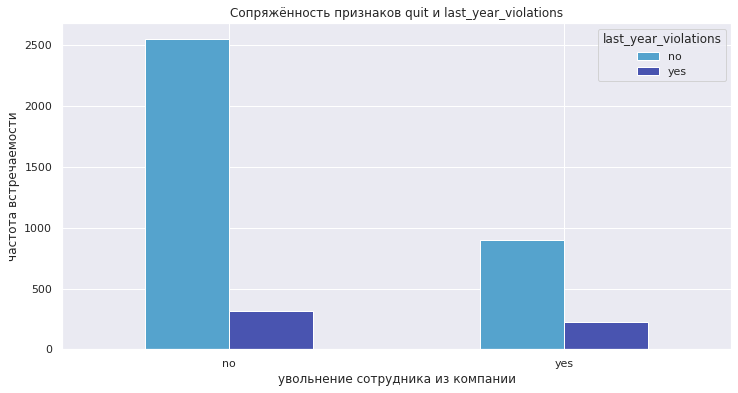

In [128]:
target_cat('last_year_violations')

<font size="3">

**Вывод**
    
Доля уволившихся сотрудников по наличию нарушений трудового договора за последний год:
- **no**:
    - не нарушали договор 3455 сотрудников, из них уволилось 900, доля уволившихся - `0.260`;
- **yes**:
    - нарушали договор 545 сотрудников, из них уволилось 228, доля уволившихся - `0.418`
    
Наибольшая доля уволившихся сотрудников по наличию нарушений трудового договора за последний год в сегменте **yes**.

---

<font size="3">

**Вывод**
    
    
Проведён корреляционный анализ и выполнено графическое исследование сопряжённости целевого и входных признаков датафрейма `data_quit`.     
    
Заметная зависимость с целевым признаком `quit` выявлена у признаков: 
- `employment_years`
- `salary`
    
Мультиколлинеарность входных признаков не выявлена.

---

### Добавление входного признака

<font size="3"> Проверим, влияет ли уровень удовлетворённости сотрудника работой в компании на то, уволится ли сотрудник.
    
Для этого визуализируем распределения признака `job_satisfaction_rate` для уволившихся и оставшихся сотрудников.

<font size="3"> Добавим целевой признак `quit` к датафрейму `target_sorted`, содержащему сортированный целевой признак `job_satisfaction_rate`, по столбцу `id`:

In [129]:
target_sorted = target_sorted.merge(target_quit, on='id', how='left')

<font size="3"> Проверим результат:

In [130]:
target_sorted.head()

,id,job_satisfaction_rate,quit
0,485046,0.790,no
1,686555,0.720,no
2,467458,0.640,no
3,418655,0.600,no
4,789145,0.750,no


<font size="3"> Визуализируем распределения признака `job_satisfaction_rate` для уволившихся и оставшихся сотрудников с помощью графика `violinplot`.

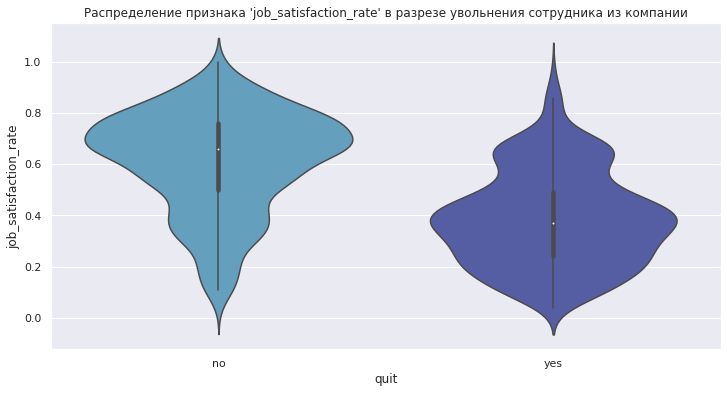

In [131]:
fig, axes = plt.subplots(figsize=(12,6))
    
sns.violinplot(data=target_sorted, x='quit', y='job_satisfaction_rate', ax=axes)
    
plt.title("Распределение признака 'job_satisfaction_rate' в разрезе увольнения сотрудника из компании")
plt.xlabel("quit")
plt.ylabel("job_satisfaction_rate");

<font size="3">

**Вывод**
    
Сотрудникам категории `1` (уволились) соответствует меньший уровень удовлетворённости работой: наибольшее количество наблюдаемых значений расположилось в промежутке от 0.2 до 0.5.
    
Среди оставшихся сотрудников преобладает более высокий уровень удовлетворённости работой: от 0.5 до 0.8.

---
<font size="3"> **Проверка гипотезы**
    
Необходимо проверить гипотезу о том, уровень удовлетворённости работой уволившихся и оставшихся в компании сотрудников различается.


Сформулируем гипотезу: 

- $H_0$ - средние значения совокупностей "уровень удовлетворённости работой уволившихся сотрудников" и "уровень удовлетворённости работой оставшихся сотрудников" равны;
- $H_1$ - среднее значение совокупности "уровень удовлетворённости работой уволившихся сотрудников" меньше среднего значения совокупности "уровень удовлетворённости работой оставшихся сотрудников".

Проверять гипотезу будем по выборочным средним признака `job_satisfaction_rate`, сгруппированного по признаку `quit`.

Для проверки используем метод `st.ttest_ind`.

Визуализация показала относительно равную дисперсию для обеих категорий сотрудников, поэтому параметр `equal_var` оставим в значении `True`.

Уровень статистической значимости установим в 0.05.

Параметр `alternative` укажем как `less` для левосторонней альтернативной гипотезы.

Проверим, можно ли отвергнуть нулевую гипотезу в пользу альтернативной.

<font size="3"> Сгруппируем данные об уровне удовлетворённости работой сотрудников из датафрейма `target_sorted`:

In [132]:
target_sorted

,id,job_satisfaction_rate,quit
0,485046,0.790,no
1,686555,0.720,no
2,467458,0.640,no
3,418655,0.600,no
4,789145,0.750,no
...,...,...,...
1995,393147,0.560,yes
1996,109582,0.140,yes
1997,305653,0.110,yes
1998,160233,0.430,no


In [133]:
quit = target_sorted[target_sorted['quit']=='yes']['job_satisfaction_rate']
not_quit = target_sorted[target_sorted['quit']=='no']['job_satisfaction_rate']

<font size="3"> Проверим гипотезу:

In [134]:
alpha = .05 

results = st.ttest_ind(quit, not_quit, alternative='less')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')
    
print('Средний уровень удовлетворённости работой среди уволившихся сотрудников:', quit.mean())
print('Средний уровень удовлетворённости работой среди оставшихся сотрудников:', not_quit.mean())

p-value: 6.155610332585965e-105
Отвергаем нулевую гипотезу
Средний уровень удовлетворённости работой среди уволившихся сотрудников: 0.38771276595744686
Средний уровень удовлетворённости работой среди оставшихся сотрудников: 0.6120403899721449


<font size="3">

**Вывод**
        
Полученное значение p-value равно $6.155610332585965⋅10^{-105}$, а значит, вероятность получения наблюдаемых результатов при условии, что нулевая гипотеза верна, очень мала.

Нулевая гипотеза отвергается в пользу альтернативной и можно заключить, что уровень удовлетворённости работой среди уволившихся сотрудников действительно меньше, чем у сотрудников, оставшихся в компании.
    
Заключим, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник.

---

<font size="3">

**Добавление признака**
    
Добавим признак `job_satisfaction_rate` к входным признакам тренировочной выборки `data_quit`.
    
Для получения предсказания признака воспользуемся лучшей моделью дерево решений для регрессии.

In [135]:
data_quit['job_satisfaction_rate'] = oscv_tree_reg.predict(data_quit)

<font size="3"> Проверим результат:

In [136]:
data_quit.sample(5)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
3204,353470,purchasing,junior,low,2,no,no,3,12000,yes,0.357
1893,511510,sales,junior,medium,3,no,no,3,27600,yes,0.517
2261,594822,hr,junior,medium,1,no,no,4,26400,yes,0.680
1308,977833,technology,junior,medium,4,no,yes,2,33600,no,0.290
971,780738,hr,junior,medium,2,no,no,3,22800,no,0.332


<font size="3">
    
Добавим признак `job_satisfaction_rate` к входным признакам тестовой выборки `features_quit`:

In [137]:
features_quit['job_satisfaction_rate'] = oscv_tree_reg.predict(features_quit)

<font size="3"> Проверим результат:

In [138]:
features_quit.sample(5)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
941,299129,hr,junior,medium,2,no,no,5,24000,0.659
1337,878762,technology,junior,medium,4,no,no,3,33600,0.508
0,485046,marketing,junior,medium,2,no,no,5,28800,0.875
1331,776489,sales,middle,low,2,no,no,4,28800,0.688
950,344889,technology,senior,medium,6,yes,no,4,62400,0.964


<font size="3">

**Вывод**
    
В шаге исследования получен вывод, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. 
    
Новый входной признак `job_satisfaction_rate` успешно добавлен в тренировочную выборку `data_quit` и тестовую выборку `features_quit`.

---

## Обучение моделей

<font size="3">
    
Выберем лучшую модель для прогноза увольнения сотрудника из компании на основе данных заказчика.
    
Для решения задачи обучим три модели: 
- `RandomForestClassifier()`;
- `KNeighborsClassifier()`;
- `LogisticRegression()`.
    
Выбор модели для прогноза сделаем на основе метрики `ROC-AUC`.

---

### Модель `RandomForestClassifier()`

<font size="3"> Напишем пайплайн для модели дерево решений классификации:
    
- для работы с категориальными данными выберем кодировщик `OrdinalEncoder`;
- пропуски в данных заполним константным значением `Unknown`;
- масштабирование количественных данных выполним с помощью `StandardScaler()`; 
- зададим перебор заданных гиперпараметров методом `OptunaSearchCV`;
- качество модели оценим с помощью метрики `ROC-AUC`.

In [139]:
RANDOM_STATE = 42

X_train = data_quit.drop(['quit', 'id'], axis=1)
y_train = data_quit['quit']
X_test = features_quit.drop(['id'], axis=1)
y_test = target_sorted['quit']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# создаём списки с названиями признаков
ord_columns = ['dept', 'level', 'workload']
ohe_columns = ['last_year_promo', 'last_year_violations']
num_columns = X_train.select_dtypes(include='number').columns.tolist()

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков + Ordinal-кодирование
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-900))
    ]
)

# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков + OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ord', ord_pipe, ord_columns),
     ('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', RandomForestClassifier(random_state=RANDOM_STATE))
])

parameters = {
    'models__max_depth': distributions.IntDistribution(2, 35),
    'models__min_samples_split': distributions.IntDistribution(2, 30),
}

oscv_forest = OptunaSearchCV(
    pipe_final,
    parameters,
    scoring='roc_auc',
    cv=5,
    n_trials=100,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_541/713459162.py:52: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_forest = OptunaSearchCV(


In [140]:
oscv_forest.fit(X_train, y_train)
print('Лучшие параметры модели:\n\n', oscv_forest.best_params_)

[I 2024-02-29 12:33:46,238] A new study created in memory with name: no-name-37db6f81-7895-4b42-9c23-3b35e1c30c70
[I 2024-02-29 12:33:47,626] Trial 0 finished with value: 0.9381071443154599 and parameters: {'models__max_depth': 17, 'models__min_samples_split': 26}. Best is trial 0 with value: 0.9381071443154599.
[I 2024-02-29 12:33:48,771] Trial 1 finished with value: 0.9360671572570943 and parameters: {'models__max_depth': 4, 'models__min_samples_split': 11}. Best is trial 0 with value: 0.9381071443154599.
[I 2024-02-29 12:33:50,273] Trial 2 finished with value: 0.936428061455484 and parameters: {'models__max_depth': 18, 'models__min_samples_split': 10}. Best is trial 0 with value: 0.9381071443154599.
[I 2024-02-29 12:33:51,768] Trial 3 finished with value: 0.9368261099738024 and parameters: {'models__max_depth': 9, 'models__min_samples_split': 6}. Best is trial 0 with value: 0.9381071443154599.
[I 2024-02-29 12:33:53,138] Trial 4 finished with value: 0.9387486488400419 and parameters

Лучшие параметры модели:

 {'models__max_depth': 6, 'models__min_samples_split': 13}


In [141]:
y_pred_forest = oscv_forest.predict_proba(X_test)[:,1]
print ('Метрика лучшей модели на кросс-валидационной выборке:', oscv_forest.best_score_)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_pred_forest):.2f}')

Метрика лучшей модели на кросс-валидационной выборке: 0.9395902877562279
Метрика ROC-AUC на тестовой выборке: 0.93


<font size="3"> 
    
**Вывод**
    
На данном этапе исследования написан пайплайн для модели случайного леса с методом оценки модели с помощью метрики `ROC-AUC`.
    
Лучше всего на тренировочных данных показали себя следующие гиперпараметры: 
- models__max_depth - `6`;
- models__min_samples_split - `13`
     
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 0.94
- Метрика ROC-AUC на тестовой выборке: 0.93

---

### Модель `KNeighborsClassifier()`

<font size="3"> Напишем пайплайн для модели k-ближайших соседей:
    
- для работы с категориальными данными выберем кодировщик `OneHotEncoder`;
- пропуски в данных заполним константным значением `Unknown`;
- масштабирование количественных данных выполним с помощью `StandardScaler()`; 
- зададим перебор заданных гиперпараметров методом `OptunaSearchCV`;
- качество модели оценим с помощью метрики `ROC-AUC`.

In [142]:
RANDOM_STATE = 42

X_train = data_quit.drop(['quit', 'id'], axis=1)
y_train = data_quit['quit']
X_test = features_quit.drop(['id'], axis=1)
y_test = target_sorted['quit']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# создаём списки с названиями признаков
ord_columns = ['dept', 'level', 'workload']
ohe_columns = ['last_year_promo', 'last_year_violations']
num_columns = X_train.select_dtypes(include='number').columns.tolist()

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков + Ordinal-кодирование
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-900))
    ]
)

# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков + OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ord', ord_pipe, ord_columns),
     ('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', KNeighborsClassifier())
])

parameters = {
    'models__n_neighbors': distributions.IntDistribution(3, 30),
    'models__weights': distributions.CategoricalDistribution(['uniform', 'distance'])
}

oscv_knn = OptunaSearchCV(
    pipe_final,
    parameters,
    scoring='roc_auc',
    cv=5,
    n_trials=100,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_541/1141043771.py:52: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_knn = OptunaSearchCV(


In [143]:
oscv_knn.fit(X_train, y_train)

print('Лучшие параметры модели:\n\n', oscv_knn.best_params_)

[I 2024-02-29 12:36:02,644] A new study created in memory with name: no-name-7aedb6b4-43d3-4e6f-8848-3e35b32573a7
[I 2024-02-29 12:36:02,860] Trial 0 finished with value: 0.9226315758063534 and parameters: {'models__n_neighbors': 15, 'models__weights': 'uniform'}. Best is trial 0 with value: 0.9226315758063534.
[I 2024-02-29 12:36:03,067] Trial 1 finished with value: 0.9219208500187019 and parameters: {'models__n_neighbors': 11, 'models__weights': 'uniform'}. Best is trial 0 with value: 0.9226315758063534.
[I 2024-02-29 12:36:03,271] Trial 2 finished with value: 0.8993336536268677 and parameters: {'models__n_neighbors': 8, 'models__weights': 'distance'}. Best is trial 0 with value: 0.9226315758063534.
[I 2024-02-29 12:36:03,533] Trial 3 finished with value: 0.8992162160108931 and parameters: {'models__n_neighbors': 11, 'models__weights': 'distance'}. Best is trial 0 with value: 0.9226315758063534.
[I 2024-02-29 12:36:03,771] Trial 4 finished with value: 0.8992676588765118 and parameter

Лучшие параметры модели:

 {'models__n_neighbors': 21, 'models__weights': 'uniform'}


In [144]:
y_pred_knn = oscv_knn.predict_proba(X_test)[:,1]
print ('Метрика лучшей модели на кросс-валидационной выборке:', oscv_knn.best_score_)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_pred_knn):.2f}')

Метрика лучшей модели на кросс-валидационной выборке: 0.9251568229717586
Метрика ROC-AUC на тестовой выборке: 0.91


<font size="3"> 
    
**Вывод**
    
Написан пайплайн для модели k-ближайших соседей с методом оценки модели с помощью метрики `ROC-AUC`.
    
Лучше всего на тренировочных данных показали себя следующие гиперпараметры: 
- models__n_neighbors - `21`;
- models__weights - `uniform`
     
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 0.92
- Метрика ROC-AUC на тестовой выборке: 0.91

---

### Модель `LogisticRegression()`

<font size="3"> Напишем пайплайн для модели логистической регрессии:
    
- для работы с категориальными данными выберем кодировщик `OneHotEncoder`;
- пропуски в данных заполним константным значением `Unknown`;
- масштабирование количественных данных выполним с помощью `StandardScaler()`; 
- зададим перебор заданных гиперпараметров методом `OptunaSearchCV`;
- качество модели оценим с помощью метрики `ROC-AUC`.

In [145]:
RANDOM_STATE = 42

X_train = data_quit.drop(['quit', 'id'], axis=1)
y_train = data_quit['quit']
X_test = features_quit.drop(['id'], axis=1)
y_test = target_sorted['quit']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# создаём списки с названиями признаков
ord_columns = ['dept', 'level', 'workload']
ohe_columns = ['last_year_promo', 'last_year_violations']
num_columns = X_train.select_dtypes(include='number').columns.tolist()

# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков + OHE-кодирование
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков + Ordinal-кодирование
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')),
     ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-900))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ord', ord_pipe, ord_columns),
     ('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='saga', 
            penalty='l1'
        ),)
])


parameters = {
    'models__C': distributions.IntDistribution(2, 30)
}

oscv_logreg = OptunaSearchCV(
    pipe_final,
    parameters,
    scoring='roc_auc',
    cv=5,
    n_trials=100,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_541/1583629280.py:56: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_logreg = OptunaSearchCV(


In [146]:
oscv_logreg.fit(X_train, y_train)

print('Лучшие параметры модели:\n\n', oscv_logreg.best_params_)

[I 2024-02-29 12:36:26,445] A new study created in memory with name: no-name-1ef18ae4-fa51-4f06-8b48-d6db06cb439c
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2024-02-29 12:36:26,848] Trial 0 finished with value: 0.9307344348082298 and parameters: {'models__C': 15}. Best is trial 0 with value: 0.9307344348082298.
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2024-02-29 12:36:27,232] Trial 1 finished with value: 0.9307282761871096 and parameters: {'models__C': 26}. Best is trial 0 with value: 0.9307344348082298.
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2024-02-29 12:36:27,587] Trial 2 finished w

Лучшие параметры модели:

 {'models__C': 11}


In [147]:
y_pred_logreg = oscv_logreg.predict_proba(X_test)[:,1]
print ('Метрика лучшей модели на кросс-валидационной выборке:', oscv_logreg.best_score_)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_pred_logreg):.2f}')

Метрика лучшей модели на кросс-валидационной выборке: 0.9307467894811087
Метрика ROC-AUC на тестовой выборке: 0.92


<font size="3"> 
    
**Вывод**
    
Написан пайплайн для модели логистической регрессии с методом оценки модели с помощью метрики `ROC-AUC`.
    
Лучше всего на тренировочных данных показали себя следующие гиперпараметры: 
- models__C - `11`
     
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 0.93
- Метрика ROC-AUC на тестовой выборке: 0.92

---
### Выбор лучшей модели

<font size="3"> 
    
Модель`RandomForestClassifier` показала лучший результат при прогнозе увольнения сотрудника. 
    
Результат работы модели соответствует критериям успеха: 
- Метрика ROC-AUC на тестовой выборке: 0.93
    
Полученная метрика удовлетворяет заданному критерию ≥ 0.91, следовательно, на основании проведённого исследования лучшей моделью для построения прогноза увольнения сотрудников выбираем `RandomForestClassifier()`.

<font size="3"> Добавим прогноз увольнения сотрудника в тестовую выборку `features_quit`:

In [148]:
features_quit['quit'] = oscv_forest.predict(features_quit)

<font size="3"> Проверим результат:

In [149]:
features_quit.sample(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
405,860774,sales,junior,medium,1,no,no,5,27600,0.702,0
1601,231661,technology,middle,medium,10,no,no,3,50400,0.495,0
1856,488314,hr,junior,low,3,no,no,4,13200,0.661,1
849,775790,sales,junior,low,2,no,no,4,15600,0.797,0
1139,921400,marketing,middle,high,5,no,no,3,61200,0.479,0
609,160980,technology,junior,medium,2,no,no,3,30000,0.369,1
225,618505,technology,middle,medium,3,no,yes,4,51600,0.520,0
1806,386959,marketing,senior,medium,8,yes,no,4,48000,0.871,0
1684,527675,sales,junior,high,5,no,no,3,30000,0.337,0
1088,997195,sales,middle,low,8,no,yes,3,27600,0.313,0


<font size="3"> 
    
**Вывод**
    
В ходе проведённого исследования получен прогноз увольнения сотрудников с помощью выбранной модели `RandomForestClassifier`. 
    
Результаты добавлены в тестовую выборку `features_quit`.

---

## Общий вывод

**Шаг 1. Изучение данных**

Перед проведением исследования данные были изучены:

- импортированы соответствующие библиотеки;
- считаны три датасета для каждой задачи:
  - предсказание уровня удовлетворённости сотрудника:  
    - тренировочная выборка сохранена в переменную `data_rate`;
    - входные признаки тестовой выборки сохранены в переменную `features_rate`;
    - целевой признак тестовой выборки сохранён в переменную `target_rate`;
  - предсказание увольнения сотрудника:
    - тренировочная выборка сохранена в переменную `data_quit`;
    - входные признаки тестовой выборки сохранены в переменную `features_quit`;
    - целевой признак тестовой выборки сохранён в переменную `target_quit`;
- изучена общая информация о полученных датафреймах;
- изучены имеющиеся пропуски в данных, тип данных, именование столбцов.

**Шаг 2. Предобработка данных**

В ходе изучения датафреймов выявлена необходимость предобработки данных:

- Проверены типы данных;
- Изучены пропуски в датафреймах;
- Проверены и обработаны дубликаты в датафреймах, в том числе и неявные.

Для заполнения пропущенных значений решено воспользоваться категорией-заглушкой, чтобы для построения прогноза модель использовала только достоверные данные.

Пропущенные значения будут обработаны в шаге пайплайна по выбранному алгоритму.

**Шаг 3. Исследовательский анализ данных**

Проведён исследовательский анализ всех признаков тренировочных датафреймов `data_rate` и `data_quit`.

***

**Количественные признаки**

Написана функция `visuals()` для построения гистограммы распределения, коробчатой диаграммы и вывода метода `describe()`.

***

1. **Датафрейм `data_rate`**

- Признак "employment_years"

Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 2 до 6 лет со средним значением в 3.7.

Выбросы и аномалии в данных отсутствуют.

***

- Признак "supervisor_evaluation"

Распределение признака асимметрично влево, большинство значений располагается в промежутке от 3 до 4 со средним значением в 3.5 баллов.

Выбросы и аномалии в данных отсутствуют.

***

- Признак "salary"

Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 23000 до 43000 со средним значением в 34000 рублей.

Выбросы и аномалии в данных отсутствуют.

***

- Признак "job_satisfaction_rate"

Целевой признак распределён нормально, большинство значений располагается в промежутке от 0.36 до 0.71 дней со средним значением в 0.53.

Выбросы и аномалии отсутствуют.

2. **Датафрейм `data_quit`**

- Признак "employment_years"

Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 2 до 6 лет со средним значением в 3.7.

Выбросы и аномалии в данных отсутствуют.

***

- Признак "supervisor_evaluation"

Распределение признака асимметрично влево, большинство значений располагается в промежутке от 3 до 4 со средним значением в 3.5 баллов.

Выбросы и аномалии в данных отсутствуют.

***

- Признак "salary"

Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 23000 до 43000 со средним значением в 34000 рублей.

Выбросы и аномалии в данных отсутствуют.

***

**Категориальные признаки**

Изучено распределение категориальных признаков датафреймов.

Написана функция `cat_visuals` для отображения распределения категориальных признаков с помощью столбчатой гистограммы.

1. **Датафрейм `data_rate`**

- Признак "dept"

Признак `dept` представлен категориями: 
- «sales»
- «technology»
- «purchasing»
- «marketing»
- «hr»

В выборке преобладает департамент «sales».

***

- Признак "level"

Признак `level` представлен категориями: 
- «junior»
- «middle»
- «senior»

В выборке преобладает категория «junior».

***

- Признак "workload"

Признак `workload` представлен категориями: 
- «low»
- «medium»
- «high»

В выборке преобладает категория «medium».

***

- Признак "last_year_promo"

Признак `last_year_promo` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

***

- Признак "last_year_violations"

Признак `last_year_violations` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

2. **Датафрейм `data_quit`**

- Признак "dept"

Признак `dept` представлен категориями: 
- «sales»
- «technology»
- «purchasing»
- «marketing»
- «hr»

В выборке преобладает департамент «sales».

***

- Признак "level"

Признак `level` представлен категориями: 
- «junior»
- «middle»
- «senior»

В выборке преобладает категория «junior».

***

- Признак "workload"

Признак `workload` представлен категориями: 
- «low»
- «medium»
- «high»

В выборке преобладает категория «medium».

***

- Признак "last_year_promo"

Признак `last_year_promo` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

***

- Признак "last_year_violations"

Признак `last_year_violations` представлен категориями: 
- «no»
- «yes»

В выборке преобладает категория «no».

***

- Признак "quit"

Целевой признак `quit` представлен категориями: 
- «1»
- «0»

В выборке преобладает категория «0» - не уволился.

***

*Вывод*

- В датафрейме `data_quit` 3 количественных и 6 категориальных признаков.
- В датафреймах `data_rate` 4 количественных и 5 категориальных признаков. 

Распределение признаков изучено, выбросов и аномалий в данных не обнаружено.


**Шаг 4. Корреляционный анализ**

Проведён корреляционный анализ признаков датафреймов `data_rate` и `data_quit`. 

**Корреляция всех признаков датафрейма**

1. **Датафрейм `data_rate`**

Проведён корреляционный анализ признаков датафрейма `data_rate` с помощью матрицы корреляций `phik_matrix()`.

*Вывод:*

Высокая зависимость с целевым признаком `job_satisfaction_rate` выявлена у признака `supervisor_evaluation`.

Заметная зависимость - у признака `last_year_violations`.
    
У остальных входных признаков умеренная либо слабая зависимость с целевым.

Мультиколлинеарность входных признаков не выявлена.

2. **Датафрейм `data_quit`**

Проведён корреляционный анализ признаков датафрейма `data_rate` с помощью матрицы корреляций `phik_matrix()`.

*Вывод:*

Заметная зависимость с целевым признаком `quit` выявлена у признаков: 
- `employment_years`
- `salary`

У остальных входных признаков умеренная либо слабая зависимость с целевым.

Мультиколлинеарность входных признаков не выявлена.

***

**Целевой признак**

**Датафрейм `data_rate`**

Признак `job_satisfaction_rate` - целевой, изучена взаимосвязь данного признака с остальными признаками датафрейма, а также проверена мультиколлинеарность признакового описания.

1. Количественные признаки

Написана функция для построения графика scatterplot, которая визуализирует зависимость целевого признака от входных количественных признаков.

Предварительно в теле функции датафрейм сграппирован по входному количественному признаку и для построения графика выбрано среднее значение каждой группы.

- Признак "employment_years"

Между целевым признаком `job_satisfaction_rate` и входным признаком `employment_years` отмечается умеренная зависимость: высокой длительности работы в компании соответствует более высокий уровень удовлетворённости сотрудника работой.

***

- Признак "supervisor_evaluation"

Между целевым признаком `job_satisfaction_rate` и входным признаком `supervisor_evaluation` отмечается высокая зависимость: более высоким значениям оценки качества работы сотрудника руководителем соответствует больший уровень удовлетворённости сотрудника работой.

***

- Признак "salary"

Между целевым признаком `job_satisfaction_rate` и входным признаком `salary` имеется слабая зависимость. 
    
Дополнительно можно отметить, что среднему уровню заработной платы (от 20000 до 70000 рублей) соответствуют средние значения целевого признака в диапазоне от 0.4 до 0.7. 

Высокому уровню заработной платы (от 80000 рублей) соответствует больший разброс значений целевого признака: такие сотрудники либо очень довольны работой, либо имеют достаточно низкий уровень удовлетворённости.

2. Категориальные признаки

Написана функция `target_cat()` для отображения распределения целевого признака `job_satisfaction_rate` в разрезе категориальных признаков датафрейма.

- Признак "dept"

Распределение целевого признака `job_satisfaction_rate` однородно для всех департаментов компании.

***

- Признак "level"

Распределение целевого признака `job_satisfaction_rate` однородно для всех уровней занимаемой должности.

***

- Признак "workload"

Распределение целевого признака `job_satisfaction_rate` однородно для всех уровней загруженности сотрудника.

***

- Признак "last_year_promo"

Сотрудникам, получившим повышение за последний год, соответствует больший уровень удовлетворённости работой.

***

- Признак "last_year_violations"

Сотрудникам, нарушавшим трудовой договор за последний год, соответствует меньший уровень удовлетворённости работой.

**Датафрейм `data_quit`**

Признак `quit` - целевой, изучена взаимосвязь данного признака с остальными признаками датафрейма, а также проверена мультиколлинеарность признакового описания.

1. Количественные признаки

Написана функция `target_num()` для отображения распределения количественных признаков датафрейма в разрезе целевого признака `quit`.

- Признак "employment_years"

Можно отметить, что сотрудникам категории `1` (уволились) соответствует меньшее количество отработанных лет: от 1 до 3.
    
Доля уволившихся среди сотрудников, проработавших от 4 и более лет в компании, значительно ниже.

***

- Признак "supervisor_evaluation"

Можно отметить, что среди сотрудников, получивших низкую оценку от руководителя, доля уволившихся значительно выше, чем среди сотрудников, получивших  оценки 4 и 5.

***

- Признак "salary"

Можно отметить, что сотрудникам категории `1` (уволились) соответствует меньший уровень заработной платы: от 10000 до 30000 рублей.
    
Доля уволившихся среди сотрудников, имеющих более высокий уровень заработной платы (от 40000 рублей), значительно ниже.

2. Категориальные признаки

Написана функция `target_cat()` для отображения сопряжённости категориальных признаков датафрейма с целевым признаком `quit`. Дополнительно выведем общее количество сотрудников в каждой категории признака и долю уволившихся сотрудников.

- Признак "dept"

Доля уволившихся сотрудников:
- **HR**:
    - в отделе 464 сотрудника, из них уволилось 116, доля уволившихся - `0.250`;
- **marketing**:
    - в отделе 582 сотрудника, из них уволилось 163, доля уволившихся - `0.280`;
- **purchasing**:
    - в отделе 588 сотрудников, из них уволилось 166, доля уволившихся - `0.282`;  
- **sales**:
    - в отделе 1438 сотрудников, из них уволилось 407, доля уволившихся - `0.283`;
- **technology**:
    - в отделе 928 сотрудников, из них уволилось 276, доля уволившихся - `0.297`
    
Наибольшая доля уволившихся сотрудников в департаменте **technology**.

***

- Признак "level"

Доля уволившихся сотрудников по уровню занимаемой должности:
- **junior**:
    - данный уровень должности имеют 1949 сотрудников, из них уволилось 1003, доля уволившихся - `0.515`;
- **middle**:
    - данный уровень должности имеют 1694 сотрудников, из них уволилось 108, доля уволившихся - `0.064`;
- **senior**:
    - данный уровень должности имеют 357 сотрудников, из них уволилось 17, доля уволившихся - `0.048`;
    
Наибольшая доля уволившихся сотрудников  по уровню занимаемой должности в сегменте **junior**.

***

- Признак "workload"

Доля уволившихся сотрудников по уровню загруженности сотрудника:
- **low**:
    - данный уровень загруженности имеют 1208 сотрудников, из них уволилось 519, доля уволившихся - `0.430`;
- **middle**:
    - данный уровень загруженности имеют 2118 сотрудников, из них уволилось 488, доля уволившихся - `0.230`;
- **high**:
    - данный уровень загруженности имеют 674 сотрудников, из них уволилось 121, доля уволившихся - `0.180`;
    
Наибольшая доля уволившихся сотрудников  по уровню загруженности сотрудника в сегменте **low**.

***

- Признак "last_year_promo"

Доля уволившихся сотрудников по наличию повышения за последний год:
- **no**:
    - не получили повышение 3887 сотрудников, из них уволилось 1127, доля уволившихся - `0.290`;
- **yes**:
    - получили повышение 113 сотрудников, из них уволилось 1, доля уволившихся - `0.009`
    
Наибольшая доля уволившихся сотрудников по наличию повышения за последний год в сегменте **no**.

***

- Признак "last_year_violations"

Доля уволившихся сотрудников по наличию нарушений трудового договора за последний год:
- **no**:
    - не нарушали договор 3455 сотрудников, из них уволилось 900, доля уволившихся - `0.260`;
- **yes**:
    - нарушали договор 545 сотрудников, из них уволилось 228, доля уволившихся - `0.418`
    
Наибольшая доля уволившихся сотрудников по наличию нарушений трудового договора за последний год в сегменте **yes**.

***

*Вывод*

Проведён корреляционный анализ и выполнено графическое исследование сопряжённости целевого и входных признаков датафреймов `data_rate` и `data_quit`.
    
Заметная зависимость с целевым признаком `job_satisfaction_rate` выявлена у признаков:
- `supervisor_evaluation`
- `last_year_violations` 

Заметная зависимость с целевым признаком `quit` выявлена у признаков: 
- `employment_years`
- `salary`

Мультиколлинеарность входных признаков отсутствует.

**Шаг 5. Предсказание уровня удовлетворённости сотрудника работой**

Первая задача исследования - выбор лучшей модели для прогноза уровня удовлетворённости сотрудника на основе данных заказчика. 

Выберем лучшую модель для прогноза уровня удовлетворённости сотрудника на основе данных заказчика.
    
Для решения задачи обучим две модели: 
- `LinearRegression()`;
- `DecisionTreeRegressor()`
    
Выбор модели для проноза сделаем на основе метрики `SMAPE`. 

Функция с формулой расчёта метрики передана в `make_scorer()` и сохранена в переменную `scorer` перед написанием пайплайнов.

**Модель `LinearRegression()`**

Написан пайплайн для модели линейной регрессии:
    
- для работы с категориальными данными выберем кодировщики `OneHotEncoder` и `OrdinalEncoder`;
- пропуски в данных заполнены константным значением `Unknown`;
- для масштабирования количественных признаков рассмотрены несколько скейлеров; 
- для перебора заданных гиперпараметров выбран метод `GridSearchCV`;
- качество модели оценивается с помощью метрики `SMAPE`.

*Вывод*

На данном этапе исследования написан пайплайн для модели линейной регрессии с методом оценки модели с помощью метрики `SMAPE`.
    
Лучше всего из заданных в гиперпараметрах скейлеров себя показал метод метод масштабирования количественных данных `MinMaxScaler()`.
    
Результат работы модели неудовлетворительный: 
- Метрика лучшей модели на кросс-валидационной выборке: 26.85
- Метрика SMAPE на тестовой выборке: 25.31
    
Данные показатели метрики не соответстуют критериям успеха: SMAPE ≤ 15. 

***

**Модель `DecisionTreeRegressor()`**

Написан пайплайн для дерева регрессии:
    
- для работы с категориальными данными выберем кодировщики `OneHotEncoder` и `OrdinalEncoder`;
- пропуски в данных заполнены константным значением `Unknown`;
- масштабирование количественных данных выполним с помощью `MinMaxScaler()`; 
- подбор гиперпараметров модели выполнено с помощью `OptunaSearchCV`;
- качество модели оценивается с помощью собственной метрики `SMAPE`.

*Вывод*

На данном этапе исследования написан пайплайн для модели дерева регрессии с методом оценки модели с помощью метрики `SMAPE`.
    
    
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 15.38
- Метрика SMAPE на тестовой выборке: 14.76
    
Модель дерево решений для регрессии показала лучший результат при прогнозе уровня удовлетворённости сотрудника. Полученная метрика симметричного среднего абсолютного процентного отклонения удовлетворяет заданному критерию ≤ 15.
    
Для получения прогноза по данным заказчика будем использовать данную модель.

**Выбор лучшей модели**

Модель дерево решений для регрессии показала лучший результат при прогнозе уровня удовлетворённости сотрудника. 
    
Полученная метрика симметричного среднего абсолютного процентного отклонения удовлетворяет заданному критерию ≤ 15, выбираем данную модель для получения прогноза удовлетворённости сотрудника работой.

**Шаг 6. Предсказание увольнения сотрудника из компании**

Вторая задача исследования - построение модели, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

Изучено влияние уровня удовлетворённости сотрудника работой в компании на то, уволится ли сотрудник.
    
Для этого визуализировано распределения признака `job_satisfaction_rate` для уволившихся и оставшихся сотрудников.

*Вывод*
    
Сотрудникам категории `1` (уволились) соответствует меньший уровень удовлетворённости работой: наибольшее количество наблюдаемых значений расположилось в промежутке от 0.2 до 0.5.
    
Среди оставшихся сотрудников преобладает более высокий уровень удовлетворённости работой: от 0.5 до 0.8.
    
***

Дополнительно проверена гипотеза о том, что уровень удовлетворённости работой уволившихся и оставшихся в компании сотрудников различается.

*Вывод*

Полученное значение p-value равно $6.155610332585965⋅10^{-105}$, а значит, вероятность получения наблюдаемых результатов при условии, что нулевая гипотеза верна, очень мала.

Нулевая гипотеза отвергается в пользу альтернативной и можно заключить, что уровень удовлетворённости работой среди уволившихся сотрудников действительно меньше, чем у сотрудников, оставшихся в компании.
    
Уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник.

**Добавление признака**
        
Для получения предсказания признака использована лучшая модель дерево решений для регрессии.

*Вывод*
    
В шаге исследования получен вывод, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. 
    
Новый входной признак `job_satisfaction_rate` успешно добавлен в тренировочную выборку `data_quit` и тестовую выборку `features_quit`.

**Обучение моделей**

Выберем лучшую модель для прогноза увольнения сотрудника из компании на основе данных заказчика.
    
Для решения задачи обучим три модели: 
- `RandomForestClassifier()`;
- `KNeighborsClassifier()`;
- `LogisticRegression()`.
    
Выбор модели для прогноза сделаем на основе метрики `ROC-AUC`.

**Модель `RandomForestClassifier()`**

Написан пайплайн для модели дерево решений классификации:
    
- для работы с категориальными данными выбран кодировщик `OrdinalEncoder`;
- пропуски в данных заполнены константным значением `Unknown`;
- масштабирование количественных данных выполнено с помощью `StandardScaler()`; 
- задан перебор заданных гиперпараметров методом `OptunaSearchCV`;
- качество модели оценивается с помощью метрики `ROC-AUC`.

*Вывод*
    
На данном этапе исследования написан пайплайн для модели случайного леса с методом оценки модели с помощью метрики `ROC-AUC`.
     
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 0.94
- Метрика ROC-AUC на тестовой выборке: 0.93

**Модель `KNeighborsClassifier()`**

Написан пайплайн для модели k-ближайших соседей:
    
- для работы с категориальными данными выбран кодировщик `OneHotEncoder`;
- пропуски в данных заполнены константным значением `Unknown`;
- масштабирование количественных данных выполнено с помощью `StandardScaler()`; 
- задан перебор заданных гиперпараметров методом `OptunaSearchCV`;
- качество модели оценивается с помощью метрики `ROC-AUC`.

*Вывод*
    
Написан пайплайн для модели k-ближайших соседей с методом оценки модели с помощью метрики `ROC-AUC`.

     
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 0.92
- Метрика ROC-AUC на тестовой выборке: 0.91

**Модель `LogisticRegression()`**

Написан пайплайн для модели логистической регрессии:
    
- для работы с категориальными данными выбран кодировщик `OneHotEncoder`;
- пропуски в данных заполнены константным значением `Unknown`;
- масштабирование количественных данных выполнено с помощью `StandardScaler()`; 
- задан перебор заданных гиперпараметров методом `OptunaSearchCV`;
- качество модели оценивается с помощью метрики `ROC-AUC`.

*Вывод*
    
Написан пайплайн для модели логистической регрессии с методом оценки модели с помощью метрики `ROC-AUC`.
     
Результат работы модели соответствует критериям успеха: 
- Метрика лучшей модели на кросс-валидационной выборке: 0.93
- Метрика ROC-AUC на тестовой выборке: 0.92

**Выбор лучшей модели**

Модель`RandomForestClassifier` показала лучший результат при прогнозе увольнения сотрудника. 
    
Результат работы модели соответствует критериям успеха: 
- Метрика ROC-AUC на тестовой выборке: 0.93
    
Полученная метрика удовлетворяет заданному критерию ≥ 0.91, следовательно, на основании проведённого исследования лучшей моделью для построения прогноза увольнения сотрудников выбираем `RandomForestClassifier()`.

*Вывод*
    
В ходе проведённого исследования получен прогноз увольнения сотрудников с помощью выбранной модели `RandomForestClassifier`. 
    
Результаты добавлены в тестовую выборку `features_quit`.

***

### Заключение

Исследование проводилось с целью оптимизации управления персоналом заказчика: полученные модели МО должны помочь избежать финансовых потерь и оттока сотрудников в компании.

На основании полученных результатов сформулированы следующие предложения:

**Удовлетворённость сотрудников работой**

В ходе исследования написана модель, которая поможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. Качество полученной модели позволяет использовать её в дальнейшем для получения прогноза.

Сбор данных об уровне удовлетворённости сотрудников работой через формы обратной связи - сложный процесс, стоит рассмотреть возможность использования полученной модели МО для предсказания снижения удовлетворённости сотрудников.

Полученный прогноз необходимо изучить HR-специалистам заказчика, так как низкая удовлетворённость работой может сигнализировать о скором увольнении сотрудника из компании.

**Увольнение сотрудников из компании**

С предсказанием увольнения сотрудников из компании сможет помочь вторая модель МО, полученная в ходе исследования.

Результаты прогноза помогут HR-специалистам заказчика вовремя заметить потенциальные риски оттока сотрудников и разработать индивидуальные меры для повышения удовлетворённости работой. 

Превентивные меры по удержанию сотрудников помогут снизить количество внезапных увольнений, а также расходы компании на поиск кандидатов на замену и риски от потери действительно ценных сотрудников.